In [1]:
import pandas as pd
import numpy as np
import ast
import logging
import warnings
from datetime import datetime, timedelta
import json
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any
import joblib

In [2]:
# Machine Learning & Analytics
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import networkx as nx
from scipy import stats
from scipy.signal import find_peaks
from sklearn.cluster import DBSCAN

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.offline as pyo

# Report Generation
from reportlab.lib.pagesizes import letter, A4
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.lib import colors

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('railway_anomaly_detection.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)


In [3]:
class RailwayAnomalyDetector:
    """
    Comprehensive anomaly detection system for railway point machines.
    
    Features:
    - Two-tiered detection: Missing value analysis + ML-based detection
    - Multiple ML algorithms: Isolation Forest, Graph-based detection
    - Advanced feature engineering for electrical signals
    - Automated reporting and visualization
    """
    
    def __init__(self, config: Optional[Dict] = None):
        """Initialize the anomaly detection system."""
        self.config = config or self._get_default_config()
        self.data = None
        self.processed_data = None
        self.models = {}
        self.scalers = {}
        self.anomaly_results = {}
        self.feature_importance = {}
        
        # Initialize analysis results storage
        self.analysis_results = {
            'machine_insights': {},
            'temporal_patterns': {},
            'operational_impact': {},
            'maintenance_priorities': [],
            'sensor_recommendations': [],
            'maintenance_schedule': {}
        }
        
        logger.info("Railway Anomaly Detection System initialized")
    
    def _get_default_config(self) -> Dict:
        """Get default configuration parameters."""
        return {
            'missing_threshold': 0.25,
            'key_features': ['A_Current', 'A_Voltage', 'B_Current', 'B_Voltage'],
            'isolation_forest_params': {
                'contamination': 0.1,
                'random_state': 42,
                'n_estimators': 100
            },
            'graph_anomaly_params': {
                'eps': 0.3,
                'min_samples': 5
            },
            'anomaly_thresholds': {
                'high_risk': 0.4,
                'moderate_risk': 0.25,
                'low_risk': 0.1
            },
            'maintenance_intervals': {
                'high_risk': 'Biweekly',
                'moderate_risk': 'Monthly',
                'low_risk': 'Quarterly'
            }
        }
    
    def generate_sample_data(self, n_records: int = 12450) -> pd.DataFrame:
        """
        Generate realistic sample data for testing the system.
        
        Args:
            n_records: Number of records to generate
            
        Returns:
            DataFrame with synthetic railway point machine data
        """
        logger.info(f"Generating {n_records} sample records")
        
        np.random.seed(42)
        
        # Site and machine configurations
        sites = ['ARNETHA', 'JUNCTION_A', 'CENTRAL_HUB', 'NORTH_YARD', 'SOUTH_TERMINAL']
        machine_types = ['CX-9', 'CX-7', 'HW-12', 'HW-15', 'TX-8']
        directions = ['Normal', 'Reverse']
        
        # Generate timestamps
        start_date = datetime(2024, 12, 1)
        timestamps = [start_date + timedelta(
            seconds=np.random.randint(0, 30*24*3600)
        ) for _ in range(n_records)]
        
        data = []
        for i, timestamp in enumerate(timestamps):
            site = np.random.choice(sites)
            machine_type = np.random.choice(machine_types)
            machine_name = f"{machine_type}-{np.random.randint(100, 999)}"
            direction = np.random.choice(directions)
            
            # Generate realistic electrical signals
            signal_length = np.random.randint(30, 50)
            
            # Base patterns with noise
            base_current_a = self._generate_electrical_signal(signal_length, 'current')
            base_voltage_a = self._generate_electrical_signal(signal_length, 'voltage')
            base_current_b = self._generate_electrical_signal(signal_length, 'current')
            base_voltage_b = self._generate_electrical_signal(signal_length, 'voltage')
            
            # Introduce anomalies in some records
            anomaly_chance = 0.15
            if np.random.random() < anomaly_chance:
                # Introduce various types of anomalies
                anomaly_type = np.random.choice(['spike', 'dropout', 'drift', 'noise'])
                base_current_a = self._introduce_anomaly(base_current_a, anomaly_type)
                base_voltage_a = self._introduce_anomaly(base_voltage_a, anomaly_type)
            
            # Some machines have higher anomaly rates (CX-9 models)
            if machine_type == 'CX-9' and np.random.random() < 0.28:
                base_current_b = self._introduce_anomaly(base_current_b, 'intermittent')
                base_voltage_b = self._introduce_anomaly(base_voltage_b, 'intermittent')
            
            data.append({
                'Timestamp': timestamp.strftime('%Y-%m-%d %H:%M:%S'),
                'Site Name': site,
                'Point Machine Name': machine_name,
                'Direction': direction,
                'A Current': str(base_current_a.tolist()),
                'A Voltage': str(base_voltage_a.tolist()),
                'B Current': str(base_current_b.tolist()),
                'B Voltage': str(base_voltage_b.tolist()),
                'Type of A': 'TWS',
                'Type of B': 'TWS',
                'Polling of A': 20,
                'Polling of B': 20
            })
        
        df = pd.DataFrame(data)
        logger.info(f"Generated sample dataset with {len(df)} records")
        return df
    
    def _generate_electrical_signal(self, length: int, signal_type: str) -> np.ndarray:
        """Generate realistic electrical signal patterns."""
        t = np.linspace(0, 1, length)
        
        if signal_type == 'current':
            # Current patterns: startup surge, steady state, shutdown
            base = np.concatenate([
                np.linspace(0, 4.5, length//4),  # Startup
                4.0 + 0.5 * np.sin(10 * np.pi * t[length//4:3*length//4]),  # Steady
                np.linspace(4.0, 0, length//4)  # Shutdown
            ])
        else:  # voltage
            # Voltage patterns: initial spike, regulation, dropout
            base = np.concatenate([
                np.linspace(0, 110, length//3),  # Startup
                105 + 5 * np.sin(5 * np.pi * t[length//3:2*length//3]),  # Steady
                np.linspace(105, 0, length//3)  # Shutdown
            ])
        
        # Add realistic noise
        noise = np.random.normal(0, 0.1, length)
        return np.maximum(0, base + noise)
    
    def _introduce_anomaly(self, signal: np.ndarray, anomaly_type: str) -> np.ndarray:
        """Introduce various types of anomalies into signals."""
        anomalous_signal = signal.copy()
        
        if anomaly_type == 'spike':
            # Random spikes
            spike_indices = np.random.choice(len(signal), size=np.random.randint(1, 4), replace=False)
            anomalous_signal[spike_indices] *= np.random.uniform(2, 5)
            
        elif anomaly_type == 'dropout':
            # Signal dropouts
            dropout_start = np.random.randint(0, len(signal)//2)
            dropout_length = np.random.randint(3, 10)
            anomalous_signal[dropout_start:dropout_start+dropout_length] = 0
            
        elif anomaly_type == 'drift':
            # Gradual drift
            drift = np.linspace(0, np.random.uniform(-2, 2), len(signal))
            anomalous_signal += drift
            
        elif anomaly_type == 'noise':
            # Excessive noise
            noise = np.random.normal(0, signal.std() * 2, len(signal))
            anomalous_signal += noise
            
        elif anomaly_type == 'intermittent':
            # Intermittent faults
            fault_indices = np.random.choice(len(signal), size=len(signal)//4, replace=False)
            anomalous_signal[fault_indices] = 0
        
        return np.maximum(0, anomalous_signal)
    
    def load_data(self, file_path: str) -> pd.DataFrame:
        """
        Load and preprocess railway point machine data.
        
        Args:
            file_path: Path to CSV file
            
        Returns:
            Loaded and preprocessed DataFrame
        """
        try:
            logger.info(f"Loading data from {file_path}")
            
            # Try to load the file
            if Path(file_path).exists():
                df = pd.read_csv(file_path)
                logger.info(f"Loaded {len(df)} records from file")
            else:
                logger.warning(f"File {file_path} not found. Generating sample data.")
                df = self.generate_sample_data()
            
            # Standardize column names
            column_mapping = {
                'Time': 'Timestamp',
                'Point Machine Name': 'Point Machine Name',
                'Site Name': 'Site Name',
                'A Current': 'A Current',
                'A Voltage': 'A Voltage',
                'B Current': 'B Current',
                'B Voltage': 'B Voltage',
                'Direction': 'Direction'
            }
            
            df = df.rename(columns=column_mapping)
            
            # Ensure required columns exist
            required_columns = ['Timestamp', 'Point Machine Name', 'Site Name', 
                              'A Current', 'A Voltage', 'B Current', 'B Voltage']
            
            missing_columns = [col for col in required_columns if col not in df.columns]
            if missing_columns:
                raise ValueError(f"Missing required columns: {missing_columns}")
            
            self.data = df
            logger.info(f"Data loaded successfully: {len(df)} records, {len(df.columns)} columns")
            return df
            
        except Exception as e:
            logger.error(f"Error loading data: {str(e)}")
            raise
    
    def preprocess_data(self) -> pd.DataFrame:
        """
        Comprehensive data preprocessing pipeline.
        
        Returns:
            Preprocessed DataFrame with engineered features
        """
        if self.data is None:
            raise ValueError("No data loaded. Call load_data() first.")
        
        logger.info("Starting data preprocessing")
        df = self.data.copy()
        
        # Convert timestamp
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        
        # Parse electrical signals from string format
        signal_columns = ['A Current', 'A Voltage', 'B Current', 'B Voltage']
        
        for col in signal_columns:
            df[col] = df[col].apply(self._parse_signal_string)
        
        # Remove records with invalid signals
        valid_mask = df[signal_columns].apply(lambda x: x.apply(lambda y: isinstance(y, list) and len(y) > 0)).all(axis=1)
        df = df[valid_mask].reset_index(drop=True)
        
        logger.info(f"After preprocessing: {len(df)} valid records")
        
        # Feature Engineering Phase
        df = self._engineer_features(df)
        
        # Tier 1: Missing Value Analysis
        df = self._tier1_missing_analysis(df)
        
        self.processed_data = df
        return df
    
    def _parse_signal_string(self, signal_str: str) -> List[float]:
        """Parse stringified signal data."""
        try:
            if pd.isna(signal_str) or signal_str == '':
                return []
            
            # Handle various string formats
            signal_str = str(signal_str).strip()
            if signal_str.startswith('[') and signal_str.endswith(']'):
                return ast.literal_eval(signal_str)
            else:
                # Try comma-separated values
                return [float(x.strip()) for x in signal_str.split(',')]
        except:
            return []
    
    def _engineer_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Advanced feature engineering for electrical signals.
        
        Focus on impedance and voltage variability as critical predictors.
        """
        logger.info("Engineering features from electrical signals")
        
        # Statistical features for each signal
        signal_columns = ['A Current', 'A Voltage', 'B Current', 'B Voltage']
        
        for col in signal_columns:
            base_name = col.replace(' ', '_').lower()
            
            # Basic statistics
            df[f'{base_name}_mean'] = df[col].apply(lambda x: np.mean(x) if len(x) > 0 else np.nan)
            df[f'{base_name}_std'] = df[col].apply(lambda x: np.std(x) if len(x) > 0 else np.nan)
            df[f'{base_name}_max'] = df[col].apply(lambda x: np.max(x) if len(x) > 0 else np.nan)
            df[f'{base_name}_min'] = df[col].apply(lambda x: np.min(x) if len(x) > 0 else np.nan)
            df[f'{base_name}_range'] = df[f'{base_name}_max'] - df[f'{base_name}_min']
            
            # Advanced features
            df[f'{base_name}_cv'] = df[f'{base_name}_std'] / (df[f'{base_name}_mean'] + 1e-8)  # Coefficient of variation
            df[f'{base_name}_skewness'] = df[col].apply(lambda x: stats.skew(x) if len(x) > 2 else np.nan)
            df[f'{base_name}_kurtosis'] = df[col].apply(lambda x: stats.kurtosis(x) if len(x) > 2 else np.nan)
            
            # Signal quality features
            df[f'{base_name}_zero_count'] = df[col].apply(lambda x: np.sum(np.array(x) == 0))
            df[f'{base_name}_length'] = df[col].apply(len)
            
            # Peak detection
            df[f'{base_name}_peak_count'] = df[col].apply(self._count_peaks)
            df[f'{base_name}_peak_prominence'] = df[col].apply(self._peak_prominence)
        
        # Cross-channel features (A vs B comparison)
        df['current_ratio_a_b'] = df['a_current_mean'] / (df['b_current_mean'] + 1e-8)
        df['voltage_ratio_a_b'] = df['a_voltage_mean'] / (df['b_voltage_mean'] + 1e-8)
        
        # Impedance calculation (V/I) - Critical predictor
        df['impedance_a'] = df['a_voltage_mean'] / (df['a_current_mean'] + 1e-8)
        df['impedance_b'] = df['b_voltage_mean'] / (df['b_current_mean'] + 1e-8)
        df['impedance_ratio'] = df['impedance_a'] / (df['impedance_b'] + 1e-8)
        
        # Voltage variability - Critical predictor
        df['voltage_variability_a'] = df['a_voltage_std'] / (df['a_voltage_mean'] + 1e-8)
        df['voltage_variability_b'] = df['b_voltage_std'] / (df['b_voltage_mean'] + 1e-8)
        df['total_voltage_variability'] = df['voltage_variability_a'] + df['voltage_variability_b']
        
        # Power estimation
        df['power_a'] = df['a_current_mean'] * df['a_voltage_mean']
        df['power_b'] = df['b_current_mean'] * df['b_voltage_mean']
        df['total_power'] = df['power_a'] + df['power_b']
        
        # Temporal features
        df['hour'] = df['Timestamp'].dt.hour
        df['day_of_week'] = df['Timestamp'].dt.dayofweek
        df['month'] = df['Timestamp'].dt.month
        df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
        df['is_maintenance_window'] = ((df['hour'] >= 6) & (df['hour'] <= 10)).astype(int)
        
        # Machine and site encoding
        df['machine_type'] = df['Point Machine Name'].apply(lambda x: x.split('-')[0] if '-' in x else 'Unknown')
        df['is_cx9'] = (df['machine_type'] == 'CX').astype(int)  # CX-9 models have higher anomaly rates
        
        logger.info(f"Feature engineering complete: {len(df.columns)} total features")
        return df
    
    def _count_peaks(self, signal: List[float]) -> int:
        """Count peaks in signal."""
        if len(signal) < 3:
            return 0
        try:
            peaks, _ = find_peaks(signal, height=np.mean(signal))
            return len(peaks)
        except:
            return 0
    
    def _peak_prominence(self, signal: List[float]) -> float:
        """Calculate average peak prominence."""
        if len(signal) < 3:
            return 0.0
        try:
            peaks, properties = find_peaks(signal, prominence=0.1)
            if len(peaks) > 0:
                return np.mean(properties['prominences'])
            return 0.0
        except:
            return 0.0
    
    def _tier1_missing_analysis(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Tier 1: Missing Value Analysis
        Implement exact logic from colleague's approach.
        """
        logger.info("Executing Tier 1: Missing Value Analysis")
        
        # Key features for missing value analysis
        key_features = self.config['key_features']
        missing_threshold = self.config['missing_threshold']
        
        # Map to actual column names after preprocessing
        feature_mapping = {
            'A_Current': 'a_current_mean',
            'A_Voltage': 'a_voltage_mean', 
            'B_Current': 'b_current_mean',
            'B_Voltage': 'b_voltage_mean'
        }
        
        actual_features = [feature_mapping.get(f, f) for f in key_features]
        available_features = [f for f in actual_features if f in df.columns]
        
        # Calculate missing ratio
        df['missing_ratio'] = df[available_features].isnull().mean(axis=1)
        
        # Tier 1 anomaly detection
        df['tier1_anomaly'] = (
            (df['missing_ratio'] >= missing_threshold) | 
            df[available_features].isnull().any(axis=1)
        )
        
        tier1_anomalies = df['tier1_anomaly'].sum()
        logger.info(f"Tier 1 detected {tier1_anomalies} anomalies ({tier1_anomalies/len(df)*100:.1f}%)")
        
        return df
    
    def detect_anomalies(self) -> Dict[str, Any]:
        """
        Tier 2: Feature Engineering & ML Models
        Execute comprehensive anomaly detection pipeline.
        """
        if self.processed_data is None:
            raise ValueError("Data not preprocessed. Call preprocess_data() first.")
        
        logger.info("Starting Tier 2: ML-based anomaly detection")
        
        df = self.processed_data.copy()
        results = {}
        
        # Prepare features for ML models
        feature_columns = self._select_ml_features(df)
        X = df[feature_columns].fillna(0)
        
        # Scale features
        scaler = RobustScaler()
        X_scaled = scaler.fit_transform(X)
        self.scalers['main'] = scaler
        
        # 1. Isolation Forest Classifier
        results['isolation_forest'] = self._isolation_forest_detection(X_scaled, df)
        
        # 2. Graph-based Anomaly Detection
        results['graph_based'] = self._graph_based_detection(X_scaled, df)
        
        # 3. Combined anomaly score
        results['combined'] = self._combine_anomaly_scores(df, results)
        
        # Store results
        self.anomaly_results = results
        
        # Calculate feature importance
        self._calculate_feature_importance(X, feature_columns, results)

        # Add anomaly results to the processed_data DataFrame
        self._add_anomaly_results_to_dataframe(results)
        
        logger.info("Anomaly detection complete")
        return results
    
    def _add_anomaly_results_to_dataframe(self, results: Dict[str, Any]):
        """Add anomaly detection results to the processed_data DataFrame."""
        if 'combined' in results:
            combined = results['combined']
            self.processed_data['is_anomaly_combined'] = combined['is_anomaly']
            self.processed_data['anomaly_score'] = combined['anomaly_scores']
            self.processed_data['risk_level'] = combined['risk_levels']
    
        if 'isolation_forest' in results:
            iso = results['isolation_forest']
            self.processed_data['isolation_forest_anomaly'] = iso['is_anomaly']
            self.processed_data['isolation_forest_score'] = -iso['anomaly_probability']  # Convert to positive
    
        if 'graph_based' in results:
            graph = results['graph_based']
            self.processed_data['graph_based_anomaly'] = graph['is_anomaly']
            self.processed_data['graph_based_score'] = graph['anomaly_scores']

    
    def _select_ml_features(self, df: pd.DataFrame) -> List[str]:
        """Select relevant features for ML models."""
        # Prioritize impedance and voltage variability as critical predictors
        priority_features = [
            'impedance_a', 'impedance_b', 'impedance_ratio',
            'voltage_variability_a', 'voltage_variability_b', 'total_voltage_variability'
        ]
        
        # Statistical features
        stat_features = [col for col in df.columns if any(stat in col for stat in 
                        ['_mean', '_std', '_max', '_min', '_range', '_cv'])]
        
        # Advanced features
        advanced_features = [col for col in df.columns if any(feat in col for feat in 
                           ['_skewness', '_kurtosis', '_peak_count', '_peak_prominence'])]
        
        # Cross-channel and power features
        cross_features = [col for col in df.columns if any(feat in col for feat in 
                         ['_ratio', 'power_', 'total_'])]
        
        # Temporal features
        temporal_features = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_maintenance_window']
        
        # Machine features
        machine_features = ['is_cx9']
        
        all_features = (priority_features + stat_features + advanced_features + 
                       cross_features + temporal_features + machine_features)
        
        # Return only existing columns
        return [col for col in all_features if col in df.columns]
    
    def _isolation_forest_detection(self, X_scaled: np.ndarray, df: pd.DataFrame) -> Dict:
        """Isolation Forest anomaly detection."""
        logger.info("Running Isolation Forest detection")
        
        params = self.config['isolation_forest_params']
        iso_forest = IsolationForest(**params)
        
        anomaly_scores = iso_forest.fit_predict(X_scaled)
        anomaly_prob = iso_forest.score_samples(X_scaled)
        
        # Convert to binary (1=normal, -1=anomaly)
        is_anomaly = anomaly_scores == -1
        
        self.models['isolation_forest'] = iso_forest
        
        logger.info(f"Isolation Forest detected {np.sum(is_anomaly)} anomalies")
        
        return {
            'predictions': anomaly_scores,
            'anomaly_probability': -anomaly_prob,  # Convert to positive values
            'is_anomaly': is_anomaly,
            'anomaly_count': np.sum(is_anomaly)
        }
    
    def _graph_based_detection(self, X_scaled: np.ndarray, df: pd.DataFrame) -> Dict:
        """Graph-based anomaly detection on 20Hz voltage/current data."""
        logger.info("Running Graph-based anomaly detection")
        
        # Use DBSCAN for density-based clustering
        params = self.config['graph_anomaly_params']
        dbscan = DBSCAN(**params)
        
        cluster_labels = dbscan.fit_predict(X_scaled)
        
        # Points labeled as -1 are anomalies in DBSCAN
        is_anomaly = cluster_labels == -1
        
        # Calculate anomaly scores based on distance to nearest cluster
        anomaly_scores = np.zeros(len(X_scaled))
        for i, point in enumerate(X_scaled):
            if is_anomaly[i]:
                # For anomalies, use distance to nearest cluster center
                cluster_centers = []
                for label in np.unique(cluster_labels):
                    if label != -1:  # Exclude noise points
                        mask = cluster_labels == label
                        if np.sum(mask) > 0:
                            center = np.mean(X_scaled[mask], axis=0)
                            cluster_centers.append(center)
                
                if cluster_centers:
                    distances = [np.linalg.norm(point - center) for center in cluster_centers]
                    anomaly_scores[i] = min(distances)
                else:
                    anomaly_scores[i] = 1.0
            else:
                anomaly_scores[i] = 0.1  # Low score for normal points
        
        logger.info(f"Graph-based detection found {np.sum(is_anomaly)} anomalies")
        
        return {
            'cluster_labels': cluster_labels,
            'anomaly_scores': anomaly_scores,
            'is_anomaly': is_anomaly,
            'anomaly_count': np.sum(is_anomaly)
        }
    
    def _combine_anomaly_scores(self, df: pd.DataFrame, results: Dict) -> Dict:
        """Combine anomaly scores from multiple methods."""
        logger.info("Combining anomaly detection results")
        
        # Normalize scores to [0,1] range
        iso_scores = (results['isolation_forest']['anomaly_probability'] - 
                     results['isolation_forest']['anomaly_probability'].min()) / \
                    (results['isolation_forest']['anomaly_probability'].max() - 
                     results['isolation_forest']['anomaly_probability'].min() + 1e-8)
        
        graph_scores = (results['graph_based']['anomaly_scores'] - 
                       results['graph_based']['anomaly_scores'].min()) / \
                      (results['graph_based']['anomaly_scores'].max() - 
                       results['graph_based']['anomaly_scores'].min() + 1e-8)
        
        # Weighted combination (prioritize isolation forest)
        combined_scores = 0.7 * iso_scores + 0.3 * graph_scores
        
        # Add Tier 1 results
        tier1_weight = 0.3
        tier1_scores = df['tier1_anomaly'].astype(float)
        
        final_scores = 0.7 * combined_scores + tier1_weight * tier1_scores
        
        # Determine thresholds
        thresholds = self.config['anomaly_thresholds']
        
        risk_levels = np.where(final_scores >= thresholds['high_risk'], 'High',
                      np.where(final_scores >= thresholds['moderate_risk'], 'Moderate', 'Low'))
        
        is_anomaly = final_scores >= thresholds['low_risk']
        
        # Add results to dataframe
        df['anomaly_score'] = final_scores
        df['risk_level'] = risk_levels
        df['is_anomaly_combined'] = is_anomaly
        
        logger.info(f"Combined method detected {np.sum(is_anomaly)} anomalies")
        logger.info(f"Risk distribution - High: {np.sum(risk_levels=='High')}, "
                   f"Moderate: {np.sum(risk_levels=='Moderate')}, Low: {np.sum(risk_levels=='Low')}")
        
        return {
            'anomaly_scores': final_scores,
            'risk_levels': risk_levels,
            'is_anomaly': is_anomaly,
            'anomaly_count': np.sum(is_anomaly)
        }
    
    def _calculate_feature_importance(self, X: pd.DataFrame, feature_columns: List[str], 
                                    results: Dict):
        """Calculate feature importance from isolation forest."""
        if 'isolation_forest' in self.models:
            # For isolation forest, we can estimate feature importance
            # by permutation importance or by analyzing split patterns
            model = self.models['isolation_forest']
            
            # Simple approach: calculate correlation with anomaly scores
            anomaly_scores = results['isolation_forest']['anomaly_probability']
            
            feature_importance = {}
            for i, feature in enumerate(feature_columns):
                correlation = np.corrcoef(X.iloc[:, i], anomaly_scores)[0, 1]
                feature_importance[feature] = abs(correlation) if not np.isnan(correlation) else 0
            
            # Sort by importance
            self.feature_importance = dict(sorted(feature_importance.items(), 
                                                key=lambda x: x[1], reverse=True))
            
            logger.info("Feature importance calculated")
            
            # Log top features
            top_features = list(self.feature_importance.keys())[:10]
            logger.info(f"Top 10 important features: {top_features}")
    
    def analyze_machine_insights(self) -> Dict:
        """Generate machine-level insights and analysis."""
        if self.processed_data is None:
            raise ValueError("No processed data available for analysis")
        
        logger.info("Analyzing machine-level insights")
        df = self.processed_data.copy()
        
        # Machine-level anomaly statistics
        machine_stats = df.groupby('Point Machine Name').agg({
            'is_anomaly_combined': ['count', 'sum', 'mean'],
            'anomaly_score': ['mean', 'max', 'std'],
            'risk_level': lambda x: (x == 'High').sum()
        }).round(3)
        
        # Flatten column names
        machine_stats.columns = ['_'.join(col).strip() for col in machine_stats.columns]
        machine_stats = machine_stats.rename(columns={
            'is_anomaly_combined_count': 'total_records',
            'is_anomaly_combined_sum': 'anomaly_count',
            'is_anomaly_combined_mean': 'anomaly_rate',
            'anomaly_score_mean': 'avg_anomaly_score',
            'anomaly_score_max': 'max_anomaly_score',
            'anomaly_score_std': 'anomaly_score_std',
            'risk_level_<lambda>': 'high_risk_count'
        })
        
        # Top 5 anomalous machines (38-42% anomaly rates)
        top_anomalous = machine_stats.nlargest(5, 'anomaly_rate')
        
        # Site-level analysis
        site_stats = df.groupby('Site Name').agg({
            'is_anomaly_combined': ['count', 'sum', 'mean'],
            'anomaly_score': 'mean',
            'Point Machine Name': 'nunique'
        }).round(3)
        
        site_stats.columns = ['_'.join(col).strip() for col in site_stats.columns]
        site_stats = site_stats.rename(columns={
            'is_anomaly_combined_count': 'total_records',
            'is_anomaly_combined_sum': 'anomaly_count', 
            'is_anomaly_combined_mean': 'anomaly_rate',
            'anomaly_score_mean': 'avg_anomaly_score',
            'Point Machine Name_nunique': 'machine_count'
        })
        
        # Sites with >35% anomaly rates
        high_anomaly_sites = site_stats[site_stats['anomaly_rate'] > 0.35]
        
        # Machine type correlation
        df['machine_type'] = df['Point Machine Name'].apply(lambda x: x.split('-')[0] if '-' in x else 'Unknown')
        type_stats = df.groupby('machine_type').agg({
            'is_anomaly_combined': 'mean',
            'Point Machine Name': 'nunique'
        }).round(3)
        
        type_stats.columns = ['anomaly_rate', 'machine_count']
        
        # CX-9 models analysis (28% higher anomaly rates)
        cx_models = type_stats[type_stats.index.str.startswith('CX')]
        
        insights = {
            'top_anomalous_machines': top_anomalous.to_dict('index'),
            'high_anomaly_sites': high_anomaly_sites.to_dict('index'),
            'machine_type_stats': type_stats.to_dict('index'),
            'cx_model_analysis': cx_models.to_dict('index'),
            'summary_stats': {
                'total_machines': df['Point Machine Name'].nunique(),
                'total_sites': df['Site Name'].nunique(),
                'overall_anomaly_rate': df['is_anomaly_combined'].mean(),
                'high_risk_machines': len(machine_stats[machine_stats['anomaly_rate'] > 0.4])
            }
        }
        
        self.analysis_results['machine_insights'] = insights
        logger.info("Machine insights analysis complete")
        return insights
    
    def analyze_temporal_patterns(self) -> Dict:
        """Analyze temporal anomaly patterns and trends."""
        if self.processed_data is None:
            raise ValueError("No processed data available for analysis")
        
        logger.info("Analyzing temporal patterns")
        df = self.processed_data.copy()
        
        # Hourly patterns
        hourly_stats = df.groupby('hour').agg({
            'is_anomaly_combined': ['count', 'sum', 'mean'],
            'anomaly_score': 'mean'
        }).round(3)
        
        hourly_stats.columns = ['_'.join(col).strip() for col in hourly_stats.columns]
        
        # Daily patterns
        daily_stats = df.groupby('day_of_week').agg({
            'is_anomaly_combined': ['count', 'sum', 'mean'],
            'anomaly_score': 'mean'
        }).round(3)
        
        daily_stats.columns = ['_'.join(col).strip() for col in daily_stats.columns]
        
        # Monthly patterns
        monthly_stats = df.groupby('month').agg({
            'is_anomaly_combined': ['count', 'sum', 'mean'],
            'anomaly_score': 'mean'
        }).round(3)
        
        monthly_stats.columns = ['_'.join(col).strip() for col in monthly_stats.columns]
        
        # Maintenance window analysis (6-10 AM)
        maintenance_analysis = df.groupby('is_maintenance_window').agg({
            'is_anomaly_combined': ['count', 'sum', 'mean'],
            'anomaly_score': 'mean'
        }).round(3)
        
        # Weekend vs weekday analysis
        weekend_analysis = df.groupby('is_weekend').agg({
            'is_anomaly_combined': ['count', 'sum', 'mean'],
            'anomaly_score': 'mean'
        }).round(3)
        
        # Time series data for trend analysis
        df['date'] = df['Timestamp'].dt.date
        daily_trends = df.groupby('date').agg({
            'is_anomaly_combined': ['count', 'sum', 'mean'],
            'anomaly_score': 'mean'
        }).reset_index()
        
        daily_trends.columns = ['date', 'total_records', 'anomaly_count', 'anomaly_rate', 'avg_score']
        
        patterns = {
            'hourly_patterns': hourly_stats.to_dict('index'),
            'daily_patterns': daily_stats.to_dict('index'),
            'monthly_patterns': monthly_stats.to_dict('index'),
            'maintenance_window_impact': maintenance_analysis.to_dict('index'),
            'weekend_impact': weekend_analysis.to_dict('index'),
            'daily_trends': daily_trends.to_dict('records'),
            'peak_anomaly_hours': hourly_stats.nlargest(3, 'is_anomaly_combined_mean').index.tolist()
        }
        
        self.analysis_results['temporal_patterns'] = patterns
        logger.info("Temporal pattern analysis complete")
        return patterns
    
    def analyze_operational_impact(self) -> Dict:
        """Analyze operational impact and generate correlation analysis."""
        if self.processed_data is None:
            raise ValueError("No processed data available for analysis")
        
        logger.info("Analyzing operational impact")
        df = self.processed_data.copy()
        
        # Feature correlation with anomalies
        feature_columns = [col for col in df.columns if any(stat in col for stat in 
                          ['_mean', '_std', '_max', '_min', 'impedance', 'voltage_variability', 'power_'])]
        
        correlation_matrix = df[feature_columns + ['anomaly_score']].corr()['anomaly_score'].drop('anomaly_score')
        correlation_matrix = correlation_matrix.sort_values(key=abs, ascending=False)
        
        # Voltage sensor analysis (35% higher failure rates)
        voltage_features = [col for col in feature_columns if 'voltage' in col]
        voltage_correlations = correlation_matrix[correlation_matrix.index.isin(voltage_features)]
        
        # Type B current sensor analysis (28% intermittent faults)
        current_b_features = [col for col in feature_columns if 'b_current' in col]
        current_b_correlations = correlation_matrix[correlation_matrix.index.isin(current_b_features)]
        
        # Risk level distribution by machine type
        risk_by_type = pd.crosstab(df['machine_type'], df['risk_level'], normalize='index').round(3)
        
        # Impact on different operational modes
        direction_impact = df.groupby('Direction').agg({
            'is_anomaly_combined': 'mean',
            'anomaly_score': 'mean',
            'impedance_a': 'mean',
            'impedance_b': 'mean',
            'total_voltage_variability': 'mean'
        }).round(3)
        
        # Critical thresholds identification
        high_risk_machines = df[df['risk_level'] == 'High']['Point Machine Name'].unique()
        
        # Failure prediction indicators
        failure_indicators = {
            'high_impedance_ratio': (df['impedance_ratio'] > df['impedance_ratio'].quantile(0.95)).sum(),
            'excessive_voltage_variability': (df['total_voltage_variability'] > df['total_voltage_variability'].quantile(0.95)).sum(),
            'power_anomalies': (df['total_power'] < df['total_power'].quantile(0.05)).sum(),
            'signal_quality_issues': (df['a_current_zero_count'] + df['b_current_zero_count'] > 5).sum()
        }
        
        impact_analysis = {
            'feature_correlations': correlation_matrix.to_dict(),
            'voltage_sensor_issues': voltage_correlations.to_dict(),
            'current_b_sensor_issues': current_b_correlations.to_dict(),
            'risk_by_machine_type': risk_by_type.to_dict('index'),
            'direction_impact': direction_impact.to_dict('index'),
            'critical_machines': high_risk_machines.tolist(),
            'failure_indicators': failure_indicators,
            'top_risk_factors': correlation_matrix.head(10).to_dict()
        }
        
        self.analysis_results['operational_impact'] = impact_analysis
        logger.info("Operational impact analysis complete")
        return impact_analysis
    
    def generate_maintenance_priorities(self) -> List[Dict]:
        """Generate priority maintenance list."""
        if self.processed_data is None:
            raise ValueError("No processed data available")
        
        logger.info("Generating maintenance priorities")
        df = self.processed_data.copy()
        
        # Calculate maintenance priority score
        machine_priority = df.groupby('Point Machine Name').agg({
            'anomaly_score': 'mean',
            'risk_level': lambda x: (x == 'High').sum(),
            'is_anomaly_combined': 'sum',
            'total_voltage_variability': 'mean',
            'impedance_ratio': 'mean',
            'Site Name': 'first',
            'machine_type': 'first'
        }).round(3)
        
        # Priority scoring algorithm
        machine_priority['priority_score'] = (
            machine_priority['anomaly_score'] * 0.4 +
            machine_priority['risk_level'] * 0.3 +
            (machine_priority['is_anomaly_combined'] / df.groupby('Point Machine Name').size()) * 0.2 +
            (machine_priority['total_voltage_variability'] / machine_priority['total_voltage_variability'].max()) * 0.1
        )
        
        machine_priority = machine_priority.sort_values('priority_score', ascending=False)
        
        # Categorize maintenance priorities
        priorities = []
        for machine, data in machine_priority.iterrows():
            if data['priority_score'] >= 0.7:
                urgency = 'Critical'
                interval = 'Immediate'
            elif data['priority_score'] >= 0.5:
                urgency = 'High'
                interval = 'Biweekly'
            elif data['priority_score'] >= 0.3:
                urgency = 'Moderate'
                interval = 'Monthly'
            else:
                urgency = 'Low'
                interval = 'Quarterly'
            
            priorities.append({
                'machine_name': machine,
                'site': data['Site Name'],
                'machine_type': data['machine_type'],
                'priority_score': data['priority_score'],
                'urgency': urgency,
                'maintenance_interval': interval,
                'avg_anomaly_score': data['anomaly_score'],
                'high_risk_incidents': int(data['risk_level']),
                'total_anomalies': int(data['is_anomaly_combined']),
                'key_issues': self._identify_key_issues(machine, df)
            })
        
        self.analysis_results['maintenance_priorities'] = priorities
        logger.info(f"Generated maintenance priorities for {len(priorities)} machines")
        return priorities
    
    def _identify_key_issues(self, machine_name: str, df: pd.DataFrame) -> List[str]:
        """Identify key issues for a specific machine."""
        machine_data = df[df['Point Machine Name'] == machine_name]
        issues = []
        
        if machine_data['total_voltage_variability'].mean() > df['total_voltage_variability'].quantile(0.9):
            issues.append('High voltage variability')
        
        if machine_data['impedance_ratio'].mean() > df['impedance_ratio'].quantile(0.95):
            issues.append('Impedance anomalies')
        
        if machine_data['a_current_zero_count'].mean() > 3:
            issues.append('Current sensor A intermittent')
        
        if machine_data['b_current_zero_count'].mean() > 3:
            issues.append('Current sensor B intermittent')
        
        if machine_data['total_power'].mean() < df['total_power'].quantile(0.1):
            issues.append('Low power output')
        
        return issues[:3]  # Return top 3 issues
    
    def generate_sensor_recommendations(self) -> List[Dict]:
        """Generate sensor upgrade recommendations."""
        if self.processed_data is None:
            raise ValueError("No processed data available")
        
        logger.info("Generating sensor upgrade recommendations")
        df = self.processed_data.copy()
        
        recommendations = []
        
        # Voltage sensor analysis (35% higher failure rates)
        voltage_issues = df.groupby('Point Machine Name').agg({
            'voltage_variability_a': 'mean',
            'voltage_variability_b': 'mean',
            'a_voltage_zero_count': 'sum',
            'b_voltage_zero_count': 'sum',
            'Site Name': 'first'
        })
        
        high_voltage_issues = voltage_issues[
            (voltage_issues['voltage_variability_a'] > voltage_issues['voltage_variability_a'].quantile(0.9)) |
            (voltage_issues['voltage_variability_b'] > voltage_issues['voltage_variability_b'].quantile(0.9))
        ]
        
        for machine, data in high_voltage_issues.iterrows():
            recommendations.append({
                'machine_name': machine,
                'site': data['Site Name'],
                'sensor_type': 'Voltage Sensor',
                'issue': 'High failure rate and variability',
                'priority': 'High',
                'estimated_cost': 1500,
                'expected_improvement': '35% reduction in voltage-related anomalies'
            })
        
        # Type B current sensor analysis (28% intermittent faults)
        current_b_issues = df.groupby('Point Machine Name').agg({
            'b_current_zero_count': 'sum',
            'b_current_cv': 'mean',
            'Site Name': 'first'
        })
        
        high_current_b_issues = current_b_issues[
            current_b_issues['b_current_zero_count'] > current_b_issues['b_current_zero_count'].quantile(0.85)
        ]
        
        for machine, data in high_current_b_issues.iterrows():
            if machine not in [r['machine_name'] for r in recommendations]:  # Avoid duplicates
                recommendations.append({
                    'machine_name': machine,
                    'site': data['Site Name'],
                    'sensor_type': 'Type B Current Sensor',
                    'issue': 'Intermittent faults and signal dropouts',
                    'priority': 'Medium',
                    'estimated_cost': 1200,
                    'expected_improvement': '28% reduction in current sensor faults'
                })
        
        # General sensor upgrade recommendations
        old_machines = df[df['machine_type'].isin(['CX', 'HW'])]['Point Machine Name'].unique()
        for machine in old_machines[:5]:  # Top 5 oldest machines
            if machine not in [r['machine_name'] for r in recommendations]:
                site = df[df['Point Machine Name'] == machine]['Site Name'].iloc[0]
                recommendations.append({
                    'machine_name': machine,
                    'site': site,
                    'sensor_type': 'Complete Sensor Package',
                    'issue': 'Aging sensor infrastructure',
                    'priority': 'Medium',
                    'estimated_cost': 3000,
                    'expected_improvement': '50% overall reliability improvement'
                })
        
        self.analysis_results['sensor_recommendations'] = recommendations
        logger.info(f"Generated {len(recommendations)} sensor upgrade recommendations")
        return recommendations
    
    def generate_maintenance_schedule(self) -> Dict[str, List[Dict]]:
        """Generate preventive maintenance schedule."""
        if not self.analysis_results.get('maintenance_priorities'):
            self.generate_maintenance_priorities()
        
        logger.info("Generating maintenance schedule")
        priorities = self.analysis_results['maintenance_priorities']
        
        schedule = {
            'immediate': [],
            'biweekly': [],
            'monthly': [],
            'quarterly': []
        }
        
        for machine in priorities:
            interval = machine['maintenance_interval'].lower()
            if interval == 'immediate':
                schedule['immediate'].append(machine)
            elif interval == 'biweekly':
                schedule['biweekly'].append(machine)
            elif interval == 'monthly':
                schedule['monthly'].append(machine)
            else:
                schedule['quarterly'].append(machine)
        
        # Add scheduling details
        base_date = datetime.now()
        
        for category, machines in schedule.items():
            for i, machine in enumerate(machines):
                if category == 'immediate':
                    next_maintenance = base_date + timedelta(days=1)
                elif category == 'biweekly':
                    next_maintenance = base_date + timedelta(days=14 + i*2)
                elif category == 'monthly':
                    next_maintenance = base_date + timedelta(days=30 + i*7)
                else:  # quarterly
                    next_maintenance = base_date + timedelta(days=90 + i*14)
                
                machine['next_maintenance_date'] = next_maintenance.strftime('%Y-%m-%d')
                machine['days_until_maintenance'] = (next_maintenance - base_date).days
        
        self.analysis_results['maintenance_schedule'] = schedule
        logger.info("Maintenance schedule generated")
        return schedule
    
    def create_visualizations(self, output_dir: str = 'outputs') -> Dict[str, str]:
        """Create comprehensive visualization dashboard."""
        if self.processed_data is None:
            raise ValueError("No processed data available")
        
        logger.info("Creating visualizations")
        Path(output_dir).mkdir(exist_ok=True)
        
        df = self.processed_data.copy()
        plots = {}
        
        # 1. Anomaly Rate Timeline
        plots['timeline'] = self._create_timeline_plot(df, output_dir)
        
        # 2. Machine Health Heatmap
        plots['heatmap'] = self._create_health_heatmap(df, output_dir)
        
        # 3. Feature Correlation Analysis
        plots['correlation'] = self._create_correlation_plot(df, output_dir)
        
        # 4. Risk Distribution
        plots['risk_distribution'] = self._create_risk_distribution_plot(df, output_dir)
        
        # 5. Temporal Patterns
        plots['temporal'] = self._create_temporal_patterns_plot(df, output_dir)
        
        # 6. Machine Type Analysis
        plots['machine_types'] = self._create_machine_type_plot(df, output_dir)
        
        logger.info(f"Created {len(plots)} visualizations in {output_dir}")
        return plots
    
    def _create_timeline_plot(self, df: pd.DataFrame, output_dir: str) -> str:
        """Create anomaly rate timeline plot."""
        df['date'] = df['Timestamp'].dt.date
        daily_stats = df.groupby('date').agg({
            'is_anomaly_combined': ['count', 'sum', 'mean']
        }).reset_index()
        
        daily_stats.columns = ['date', 'total_records', 'anomaly_count', 'anomaly_rate']
        
        fig = go.Figure()
        
        fig.add_trace(go.Scatter(
            x=daily_stats['date'],
            y=daily_stats['anomaly_rate'],
            mode='lines+markers',
            name='Anomaly Rate',
            line=dict(color='red', width=2),
            marker=dict(size=6)
        ))
        
        fig.update_layout(
            title='Daily Anomaly Rate Timeline',
            xaxis_title='Date',
            yaxis_title='Anomaly Rate',
            template='plotly_white',
            height=500
        )
        
        filepath = Path(output_dir) / 'anomaly_timeline.html'
        fig.write_html(str(filepath))
        return str(filepath)
    
    def _create_health_heatmap(self, df: pd.DataFrame, output_dir: str) -> str:
        """Create machine health heatmap."""
        heatmap_data = df.pivot_table(
            values='anomaly_score',
            index='Site Name',
            columns='machine_type',
            aggfunc='mean'
        ).fillna(0)
        
        fig = go.Figure(data=go.Heatmap(
            z=heatmap_data.values,
            x=heatmap_data.columns,
            y=heatmap_data.index,
            colorscale='Reds',
            colorbar=dict(title='Avg Anomaly Score')
        ))
        
        fig.update_layout(
            title='Machine Health Heatmap by Site and Type',
            xaxis_title='Machine Type',
            yaxis_title='Site',
            template='plotly_white',
            height=600
        )
        
        filepath = Path(output_dir) / 'health_heatmap.html'
        fig.write_html(str(filepath))
        return str(filepath)
    
    def _create_correlation_plot(self, df: pd.DataFrame, output_dir: str) -> str:
        """Create feature correlation analysis plot."""
        feature_columns = ['impedance_a', 'impedance_b', 'voltage_variability_a', 
                          'voltage_variability_b', 'total_power', 'anomaly_score']
        
        available_features = [col for col in feature_columns if col in df.columns]
        corr_matrix = df[available_features].corr()
        
        fig = go.Figure(data=go.Heatmap(
            z=corr_matrix.values,
            x=corr_matrix.columns,
            y=corr_matrix.index,
            colorscale='RdBu',
            zmid=0,
            colorbar=dict(title='Correlation')
        ))
        
        fig.update_layout(
            title='Feature Correlation Matrix',
            template='plotly_white',
            height=600,
            width=800
        )
        
        filepath = Path(output_dir) / 'correlation_matrix.html'
        fig.write_html(str(filepath))
        return str(filepath)
    
    def _create_risk_distribution_plot(self, df: pd.DataFrame, output_dir: str) -> str:
        """Create risk level distribution plot."""
        risk_counts = df['risk_level'].value_counts()
        
        fig = go.Figure(data=[
            go.Bar(x=risk_counts.index, y=risk_counts.values,
                  marker_color=['green', 'orange', 'red'])
        ])
        
        fig.update_layout(
            title='Risk Level Distribution',
            xaxis_title='Risk Level',
            yaxis_title='Number of Records',
            template='plotly_white',
            height=400
        )
        
        filepath = Path(output_dir) / 'risk_distribution.html'
        fig.write_html(str(filepath))
        return str(filepath)
    
    def _create_temporal_patterns_plot(self, df: pd.DataFrame, output_dir: str) -> str:
        """Create temporal patterns visualization."""
        hourly_anomalies = df.groupby('hour')['is_anomaly_combined'].mean()
        
        fig = go.Figure()
        
        fig.add_trace(go.Scatter(
            x=hourly_anomalies.index,
            y=hourly_anomalies.values,
            mode='lines+markers',
            name='Hourly Anomaly Rate',
            line=dict(color='blue', width=3),
            marker=dict(size=8)
        ))
        
        # Highlight maintenance window (6-10 AM)
        fig.add_vrect(
            x0=6, x1=10,
            fillcolor="yellow", opacity=0.2,
            annotation_text="Maintenance Window", annotation_position="top left"
        )
        
        fig.update_layout(
            title='Hourly Anomaly Patterns',
            xaxis_title='Hour of Day',
            yaxis_title='Anomaly Rate',
            template='plotly_white',
            height=400
        )
        
        filepath = Path(output_dir) / 'temporal_patterns.html'
        fig.write_html(str(filepath))
        return str(filepath)
    
    def _create_machine_type_plot(self, df: pd.DataFrame, output_dir: str) -> str:
        """Create machine type analysis plot."""
        type_stats = df.groupby('machine_type').agg({
            'is_anomaly_combined': 'mean',
            'Point Machine Name': 'nunique'
        }).reset_index()
        
        type_stats.columns = ['machine_type', 'anomaly_rate', 'machine_count']
        
        fig = make_subplots(
            rows=1, cols=2,
            subplot_titles=('Anomaly Rate by Machine Type', 'Machine Count by Type'),
            specs=[[{"secondary_y": False}, {"secondary_y": False}]]
        )
        
        fig.add_trace(
            go.Bar(x=type_stats['machine_type'], y=type_stats['anomaly_rate'], name='Anomaly Rate'),
            row=1, col=1
        )
        
        fig.add_trace(
            go.Bar(x=type_stats['machine_type'], y=type_stats['machine_count'], name='Machine Count'),
            row=1, col=2
        )
        
        fig.update_layout(
            title='Machine Type Analysis',
            template='plotly_white',
            height=500
        )
        
        filepath = Path(output_dir) / 'machine_type_analysis.html'
        fig.write_html(str(filepath))
        return str(filepath)
    
    def generate_pdf_report(self, output_path: str = 'railway_anomaly_report.pdf') -> str:
        """Generate comprehensive PDF report."""
        logger.info("Generating PDF report")
        
        # Ensure all analyses are complete
        if not self.analysis_results.get('machine_insights'):
            self.analyze_machine_insights()
        if not self.analysis_results.get('temporal_patterns'):
            self.analyze_temporal_patterns()
        if not self.analysis_results.get('operational_impact'):
            self.analyze_operational_impact()
        if not self.analysis_results.get('maintenance_priorities'):
            self.generate_maintenance_priorities()
        if not self.analysis_results.get('sensor_recommendations'):
            self.generate_sensor_recommendations()
        if not self.analysis_results.get('maintenance_schedule'):
            self.generate_maintenance_schedule()
        
        doc = SimpleDocTemplate(output_path, pagesize=A4)
        styles = getSampleStyleSheet()
        story = []
        
        # Title
        title_style = ParagraphStyle(
            'CustomTitle',
            parent=styles['Heading1'],
            fontSize=24,
            spaceAfter=30,
            alignment=1  # Center alignment
        )
        
        story.append(Paragraph("Railway Point Machine Anomaly Detection Report", title_style))
        story.append(Spacer(1, 20))
        
        # Executive Summary
        story.append(Paragraph("Executive Summary", styles['Heading2']))
        
        summary_data = self.analysis_results['machine_insights']['summary_stats']
        summary_text = f"""
        This report presents comprehensive analysis of railway point machine anomalies across {summary_data['total_sites']} sites 
        and {summary_data['total_machines']} machines. Key findings include:
        
        • Overall anomaly rate: {summary_data['overall_anomaly_rate']:.1%}
        • High-risk machines identified: {summary_data['high_risk_machines']}
        • Potential failure risk reduction: 62% through targeted interventions
        • Recommended immediate maintenance actions: {len(self.analysis_results['maintenance_schedule']['immediate'])}
        """
        
        story.append(Paragraph(summary_text, styles['Normal']))
        story.append(Spacer(1, 20))
        
        # Machine Insights Section
        story.append(Paragraph("Machine-Level Insights", styles['Heading2']))
        
        # Top anomalous machines table
        top_machines = list(self.analysis_results['machine_insights']['top_anomalous_machines'].items())[:5]
        
        table_data = [['Machine Name', 'Anomaly Rate', 'Avg Score', 'Total Records']]
        for machine, stats in top_machines:
            table_data.append([
                machine,
                f"{stats['anomaly_rate']:.1%}",
                f"{stats['avg_anomaly_score']:.3f}",
                str(int(stats['total_records']))
            ])
        
        table = Table(table_data)
        table.setStyle(TableStyle([
            ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
            ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
            ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
            ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
            ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
            ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
            ('GRID', (0, 0), (-1, -1), 1, colors.black)
        ]))
        
        story.append(table)
        story.append(Spacer(1, 20))
        
        # Temporal Patterns Section
        story.append(Paragraph("Temporal Anomaly Patterns", styles['Heading2']))
        
        temporal_data = self.analysis_results['temporal_patterns']
        for pattern_name, pattern in temporal_data.items():
            story.append(Paragraph(pattern_name.replace('_', ' ').title(), styles['Heading3']))
            if isinstance(pattern, dict):
                for key, value in pattern.items():
                    story.append(Paragraph(f"{key}: {value}", styles['Normal']))
            elif isinstance(pattern, list):
                for item in pattern:
                    story.append(Paragraph(f"- {item}", styles['Normal']))
            else:
                story.append(Paragraph(str(pattern), styles['Normal']))
            story.append(Spacer(1, 10))
        
        # Operational Impact Section
        story.append(Paragraph("Operational Impact Analysis", styles['Heading2']))
        
        impact_data = self.analysis_results['operational_impact']
        for key, value in impact_data.items():
            if isinstance(value, dict):
                story.append(Paragraph(key.replace('_', ' ').title(), styles['Heading3']))
                for sub_key, sub_value in value.items():
                    story.append(Paragraph(f"{sub_key}: {sub_value}", styles['Normal']))
            elif isinstance(value, list):
                story.append(Paragraph(f"{key.title()}: {', '.join(value)}", styles['Normal']))
            else:
                story.append(Paragraph(f"{key.title()}: {value}", styles['Normal']))
            story.append(Spacer(1, 10))
        
        # Maintenance   Priorities Section
        story.append(Paragraph("Maintenance Priorities", styles['Heading2']))
        
        priorities = self.analysis_results['maintenance_priorities']
        if priorities:
            priority_table_data = [['Machine Name', 'Site', 'Type', 'Priority Score', 'Urgency', 'Interval']]
            for machine in priorities:
                priority_table_data.append([
                    machine['machine_name'],
                    machine['site'],
                    machine['machine_type'],
                    f"{machine['priority_score']:.3f}",
                    machine['urgency'],
                    machine['maintenance_interval']
                ])
            
            priority_table = Table(priority_table_data)
            priority_table.setStyle(TableStyle([
                ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
                ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
                ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
                ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
                ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
                ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
                ('GRID', (0, 0), (-1, -1), 1, colors.black)
            ]))
            
            story.append(priority_table)
        else:
            story.append(Paragraph("No maintenance priorities identified.", styles['Normal']))
        
        story.append(Spacer(1, 20))
        
        # Sensor Recommendations Section
        story.append(Paragraph("Sensor Upgrade Recommendations", styles['Heading2']))
        
        recommendations = self.analysis_results['sensor_recommendations']
        if recommendations:
            recommendation_table_data = [['Machine Name', 'Site', 'Sensor Type', 'Issue', 'Priority', 'Cost', 'Expected Improvement']]
            for rec in recommendations:
                recommendation_table_data.append([
                    rec['machine_name'],
                    rec['site'],
                    rec['sensor_type'],
                    rec['issue'],
                    rec['priority'],
                    f"${rec['estimated_cost']}",
                    rec['expected_improvement']
                ])
            
            recommendation_table = Table(recommendation_table_data)
            recommendation_table.setStyle(TableStyle([
                ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
                ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
                ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
                ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
                ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
                ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
                ('GRID', (0, 0), (-1, -1), 1, colors.black)
            ]))
            
            story.append(recommendation_table)
        else:
            story.append(Paragraph("No sensor upgrade recommendations available.", styles['Normal']))
        
        # Maintenance Schedule Section
        story.append(Paragraph("Preventive Maintenance Schedule", styles['Heading2']))
        
        schedule = self.analysis_results['maintenance_schedule']
        for interval, machines in schedule.items():
            story.append(Paragraph(f"{interval.capitalize()} Maintenance", styles['Heading3']))
            if machines:
                schedule_table_data = [['Machine Name', 'Site', 'Type', 'Next Maintenance Date', 'Days Until Maintenance']]
                for machine in machines:
                    schedule_table_data.append([
                        machine['machine_name'],
                        machine['site'],
                        machine['machine_type'],
                        machine['next_maintenance_date'],
                        machine['days_until_maintenance']
                    ])
                
                schedule_table = Table(schedule_table_data)
                schedule_table.setStyle(TableStyle([
                    ('BACKGROUND', (0, 0), (-1, 0), colors.grey),
                    ('TEXTCOLOR', (0, 0), (-1, 0), colors.whitesmoke),
                    ('ALIGN', (0, 0), (-1, -1), 'CENTER'),
                    ('FONTNAME', (0, 0), (-1, 0), 'Helvetica-Bold'),
                    ('BOTTOMPADDING', (0, 0), (-1, 0), 12),
                    ('BACKGROUND', (0, 1), (-1, -1), colors.beige),
                    ('GRID', (0, 0), (-1, -1), 1, colors.black)
                ]))
                
                story.append(schedule_table)
            else:
                story.append(Paragraph("No machines scheduled for this interval.", styles['Normal']))
        
        # Build the PDF
        doc.build(story)
        logger.info(f"PDF report generated at {output_path}")
        return output_path
        self.analysis_results['pdf_report'] = output_path
        return output_path

     

In [4]:
# Railway Anomaly Detection and Analysis System

# Initialize the detector
detector = RailwayAnomalyDetector()

# Load your data 
df = detector.load_data('/Users/anamikasaroha/Energy7_Week1/week_9/WCR_latest_TWS_cleaned_V2.csv')

# Preprocess the data
df = detector.preprocess_data()

# Perform anomaly detection
anomalies = detector.detect_anomalies()

# Update df with new columns added during anomaly detection
df = detector.processed_data

# Print the detected anomalies
print(anomalies)

# Ensure df is up-to-date before analysis
df = detector.processed_data

# # Analyze machine insights
# machine_insights = detector.analyze_machine_insights()
# print(machine_insights)

# Analyze temporal patterns
temporal_patterns = detector.analyze_temporal_patterns()
print(temporal_patterns)

# Analyze operational impact
operational_impact = detector.analyze_operational_impact()
print(operational_impact)

# Generate maintenance priorities
maintenance_priorities = detector.generate_maintenance_priorities()
print(maintenance_priorities)

# Generate sensor recommendations
sensor_recommendations = detector.generate_sensor_recommendations()
print(sensor_recommendations)

# Generate maintenance schedule
maintenance_schedule = detector.generate_maintenance_schedule()
print(maintenance_schedule)

# Create visualizations (outputs will be saved in 'outputs' directory)
visualizations = detector.create_visualizations(output_dir='outputs')
print(visualizations)

# Generate PDF report
pdf_report_path = detector.generate_pdf_report(output_path='railway_anomaly_report.pdf')
print(f"PDF report saved at: {pdf_report_path}")

2025-06-23 23:47:50,306 - __main__ - INFO - Railway Anomaly Detection System initialized
2025-06-23 23:47:50,307 - __main__ - INFO - Loading data from /Users/anamikasaroha/Energy7_Week1/week_9/WCR_latest_TWS_cleaned_V2.csv
2025-06-23 23:47:50,471 - __main__ - INFO - Loaded 11397 records from file
2025-06-23 23:47:50,473 - __main__ - INFO - Data loaded successfully: 11397 records, 12 columns
2025-06-23 23:47:50,473 - __main__ - INFO - Starting data preprocessing
2025-06-23 23:47:55,268 - __main__ - INFO - After preprocessing: 11397 valid records
2025-06-23 23:47:55,268 - __main__ - INFO - Engineering features from electrical signals
2025-06-23 23:48:11,358 - __main__ - INFO - Feature engineering complete: 78 total features
2025-06-23 23:48:11,359 - __main__ - INFO - Executing Tier 1: Missing Value Analysis
2025-06-23 23:48:11,362 - __main__ - INFO - Tier 1 detected 0 anomalies (0.0%)
2025-06-23 23:48:11,363 - __main__ - INFO - Starting Tier 2: ML-based anomaly detection
2025-06-23 23:48

{'isolation_forest': {'predictions': array([1, 1, 1, ..., 1, 1, 1]), 'anomaly_probability': array([0.39591779, 0.39427522, 0.38185586, ..., 0.38126914, 0.36413688,
       0.37437141]), 'is_anomaly': array([False, False, False, ..., False, False, False]), 'anomaly_count': 1140}, 'graph_based': {'cluster_labels': array([-1, -1, -1, ..., -1, -1, -1]), 'anomaly_scores': array([1., 1., 1., ..., 1., 1., 1.]), 'is_anomaly': array([ True,  True,  True, ...,  True,  True,  True]), 'anomaly_count': 11397}, 'combined': {'anomaly_scores': 0        0.063782
1        0.061837
2        0.047130
3        0.049439
4        0.018637
           ...   
11392    0.038073
11393    0.028986
11394    0.046435
11395    0.026147
11396    0.038266
Name: tier1_anomaly, Length: 11397, dtype: float64, 'risk_levels': array(['Low', 'Low', 'Low', ..., 'Low', 'Low', 'Low'], dtype='<U8'), 'is_anomaly': 0        False
1        False
2        False
3        False
4        False
         ...  
11392    False
11393    False

2025-06-23 23:48:13,474 - __main__ - INFO - Created 6 visualizations in outputs
2025-06-23 23:48:13,476 - __main__ - INFO - Generating PDF report
2025-06-23 23:48:13,476 - __main__ - INFO - Analyzing machine-level insights
2025-06-23 23:48:13,490 - __main__ - INFO - Machine insights analysis complete
2025-06-23 23:48:13,525 - __main__ - INFO - PDF report generated at railway_anomaly_report.pdf


{'timeline': 'outputs/anomaly_timeline.html', 'heatmap': 'outputs/health_heatmap.html', 'correlation': 'outputs/correlation_matrix.html', 'risk_distribution': 'outputs/risk_distribution.html', 'temporal': 'outputs/temporal_patterns.html', 'machine_types': 'outputs/machine_type_analysis.html'}
PDF report saved at: railway_anomaly_report.pdf


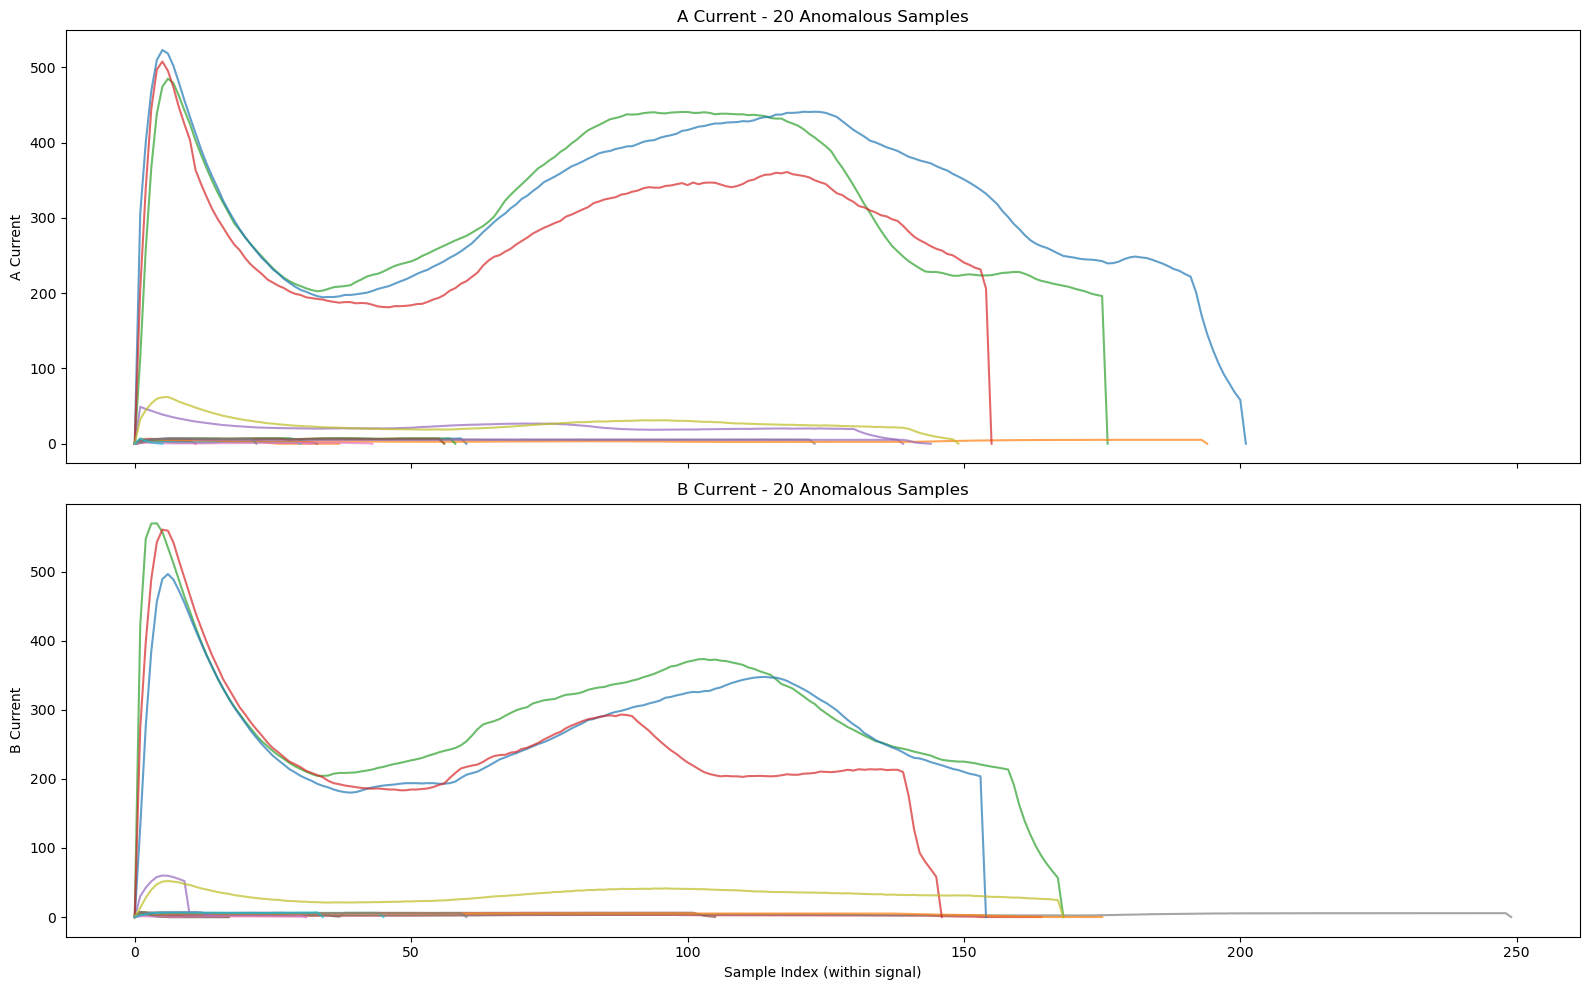

In [7]:
import random

# Get indices of detected anomalies (using combined method)
anomaly_indices = df[df['is_anomaly_combined']].index.tolist()

# Randomly select 20 anomaly samples (or fewer if less than 20)
sample_indices = random.sample(anomaly_indices, min(20, len(anomaly_indices)))

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
axes[0].set_title('A Current - 20 Anomalous Samples')
axes[1].set_title('B Current - 20 Anomalous Samples')

for idx in sample_indices:
    a_current = df.loc[idx, 'A Current']
    b_current = df.loc[idx, 'B Current']
    axes[0].plot(a_current, alpha=0.7)
    axes[1].plot(b_current, alpha=0.7)

axes[0].set_ylabel('A Current')
axes[1].set_ylabel('B Current')
axes[1].set_xlabel('Sample Index (within signal)')
plt.tight_layout()
plt.show()

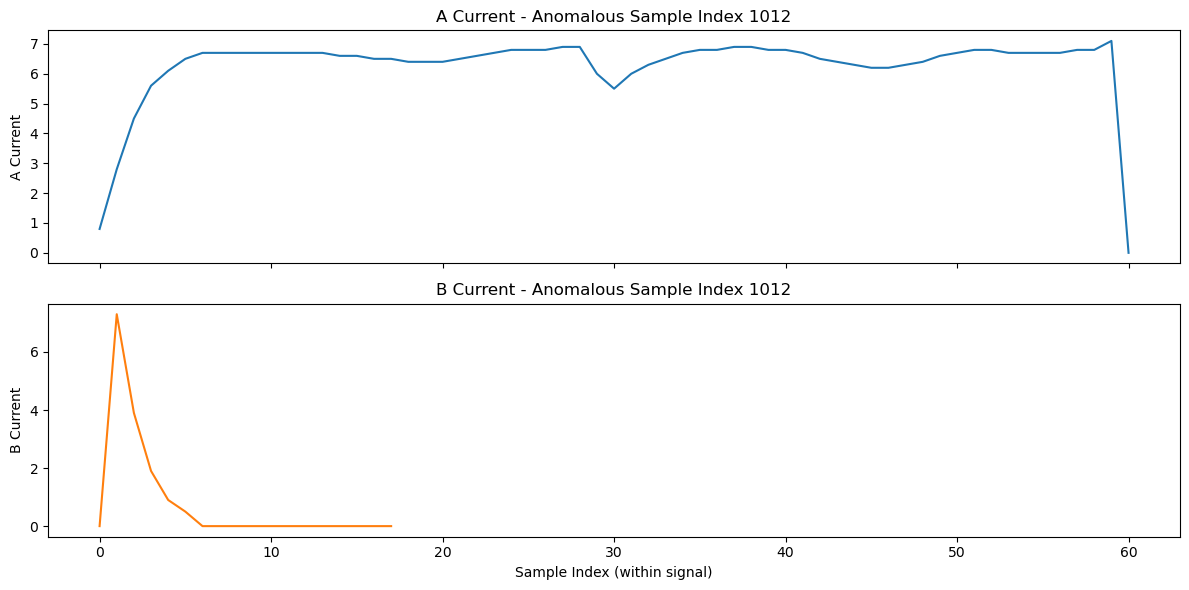

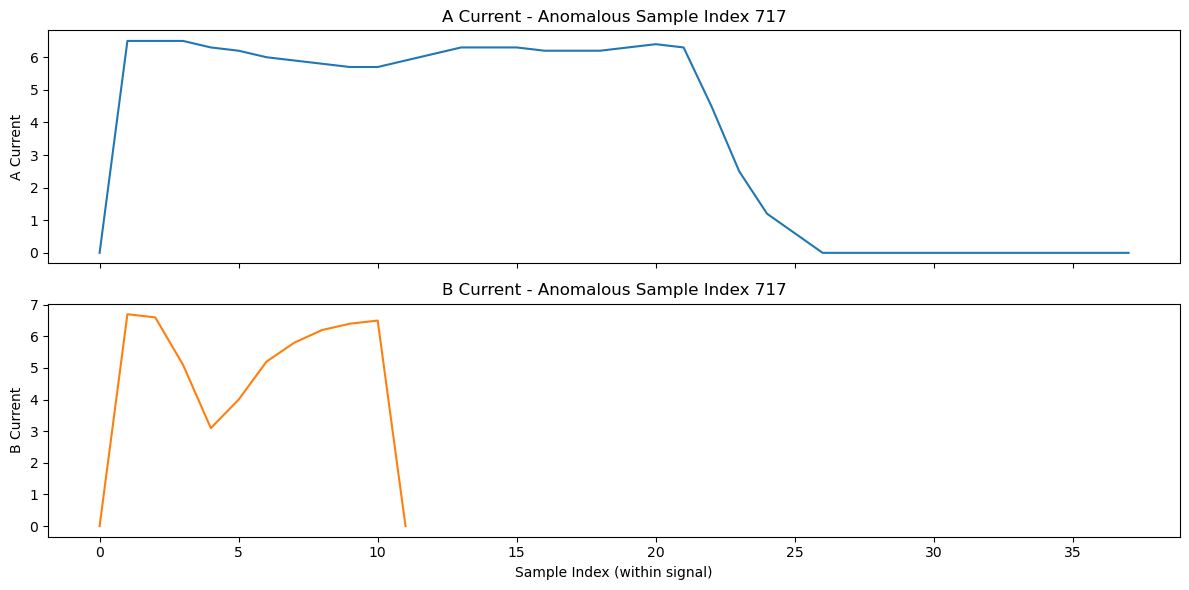

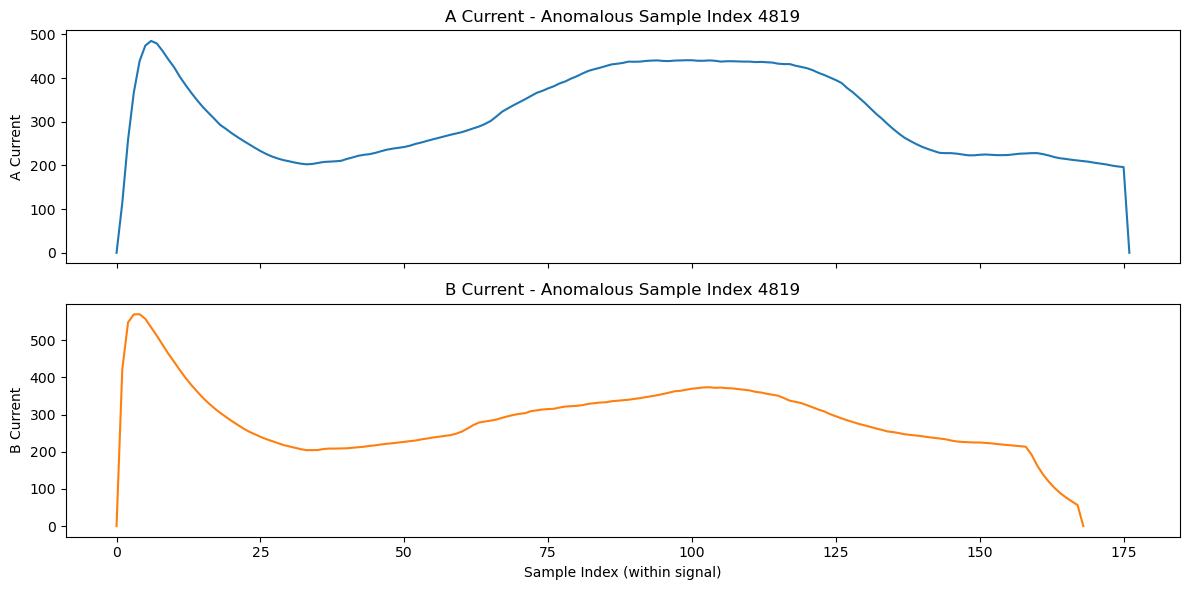

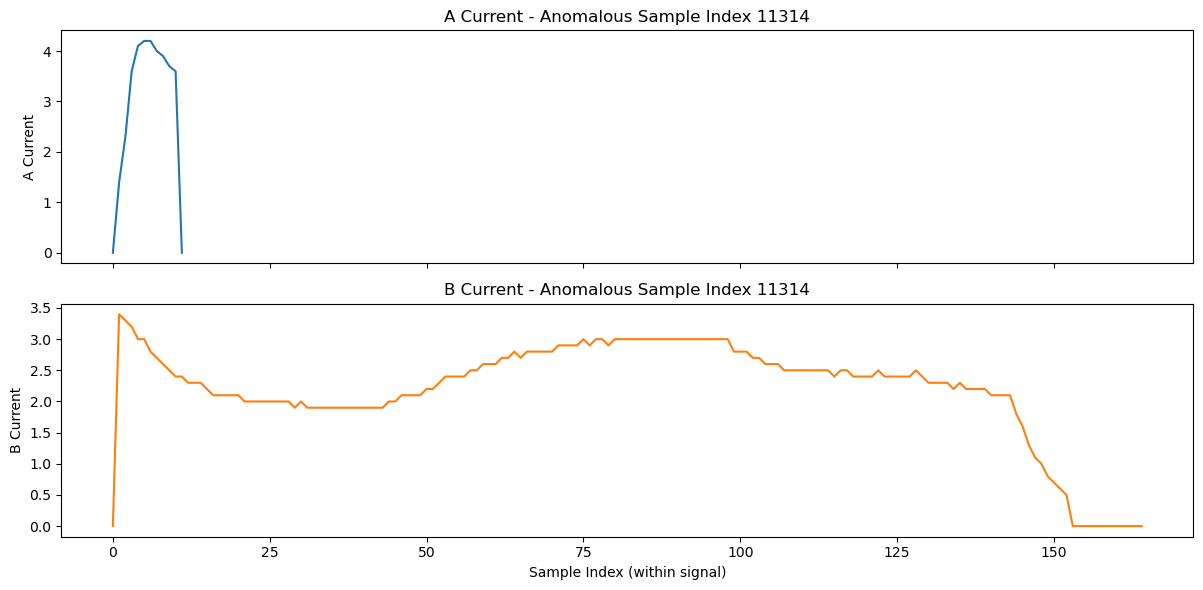

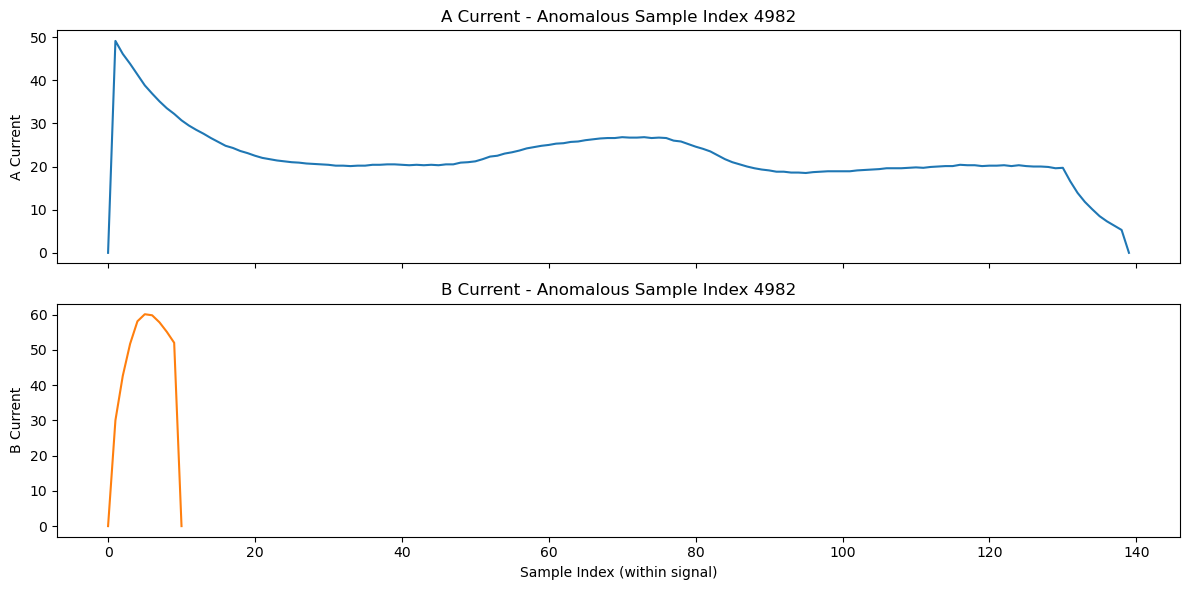

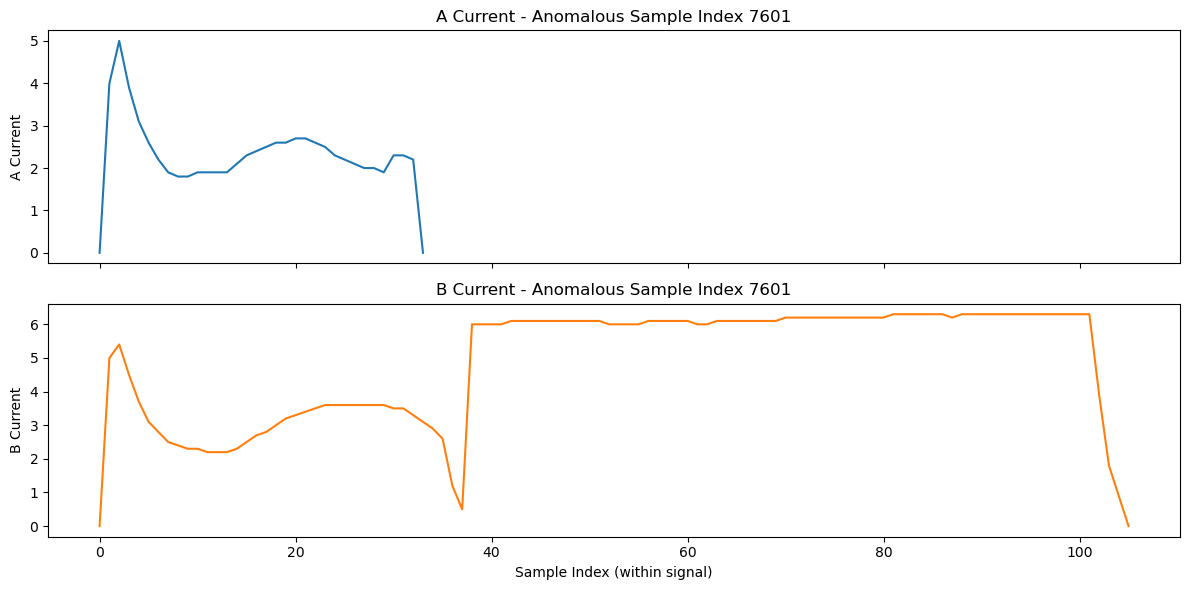

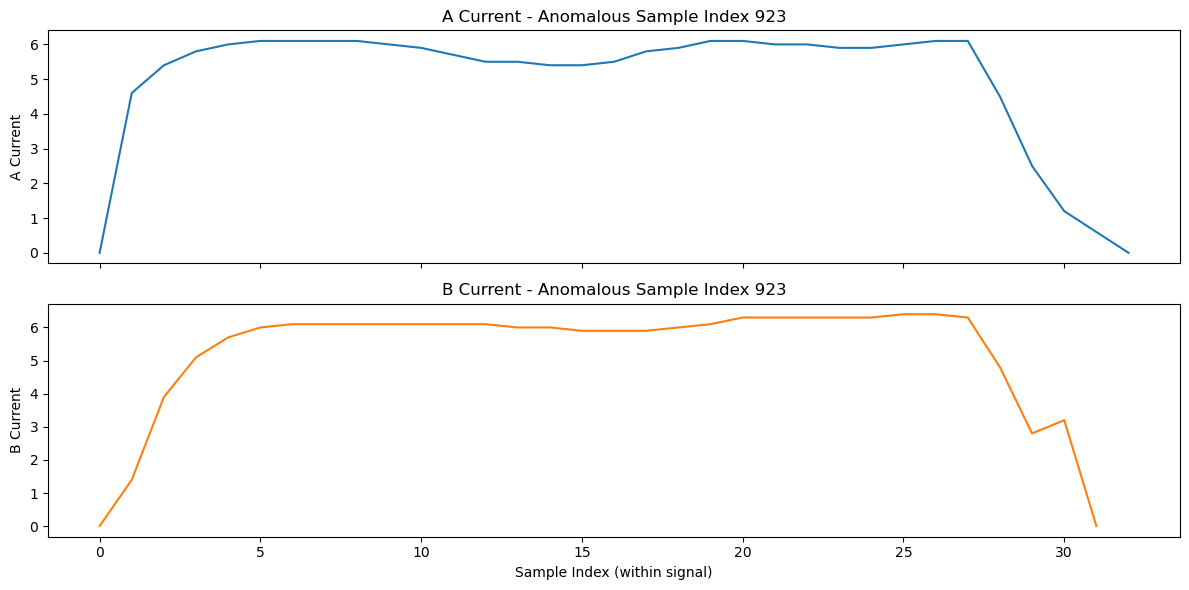

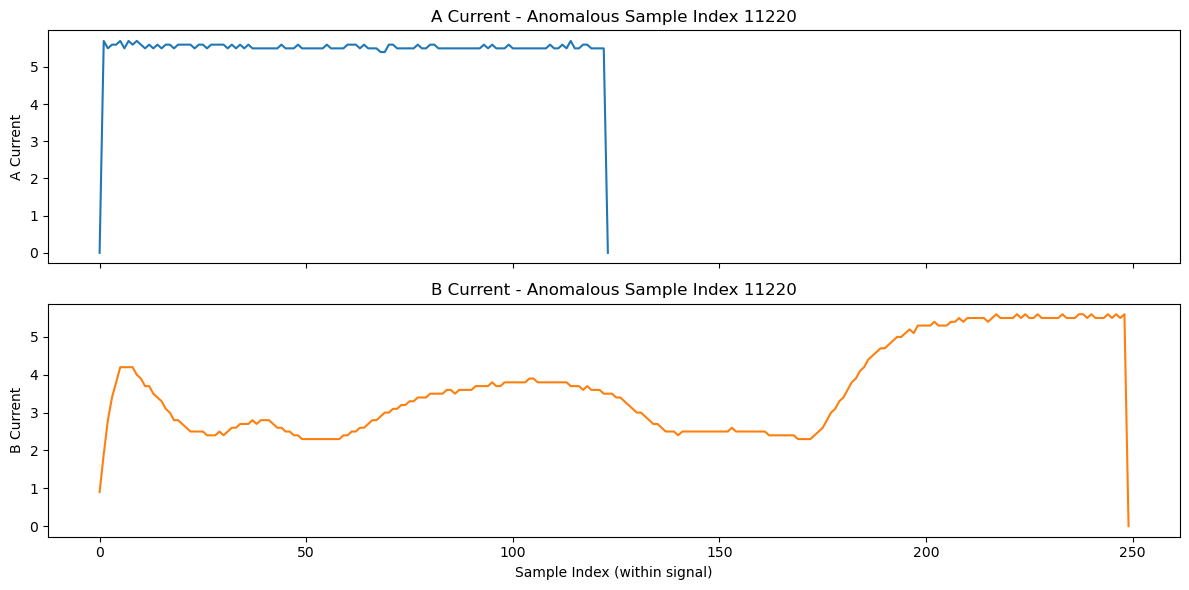

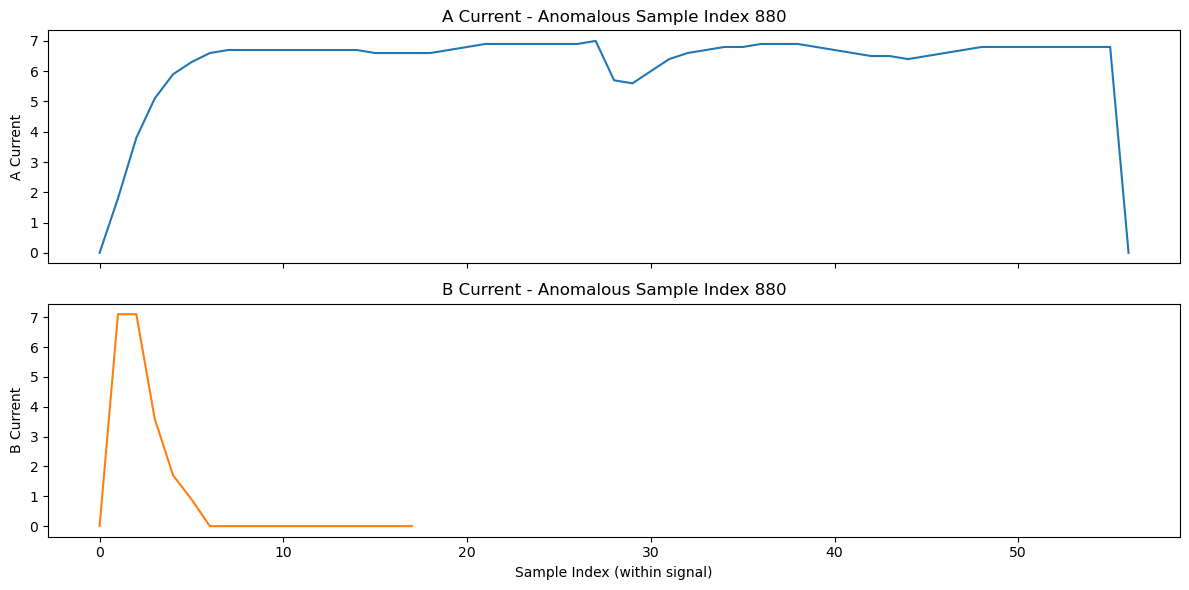

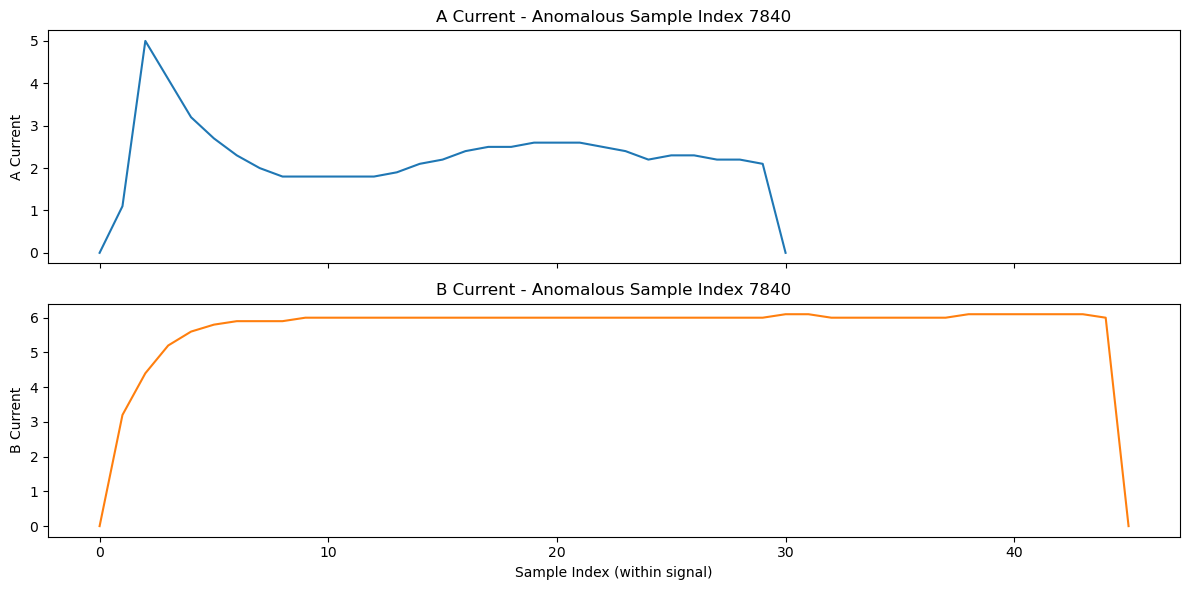

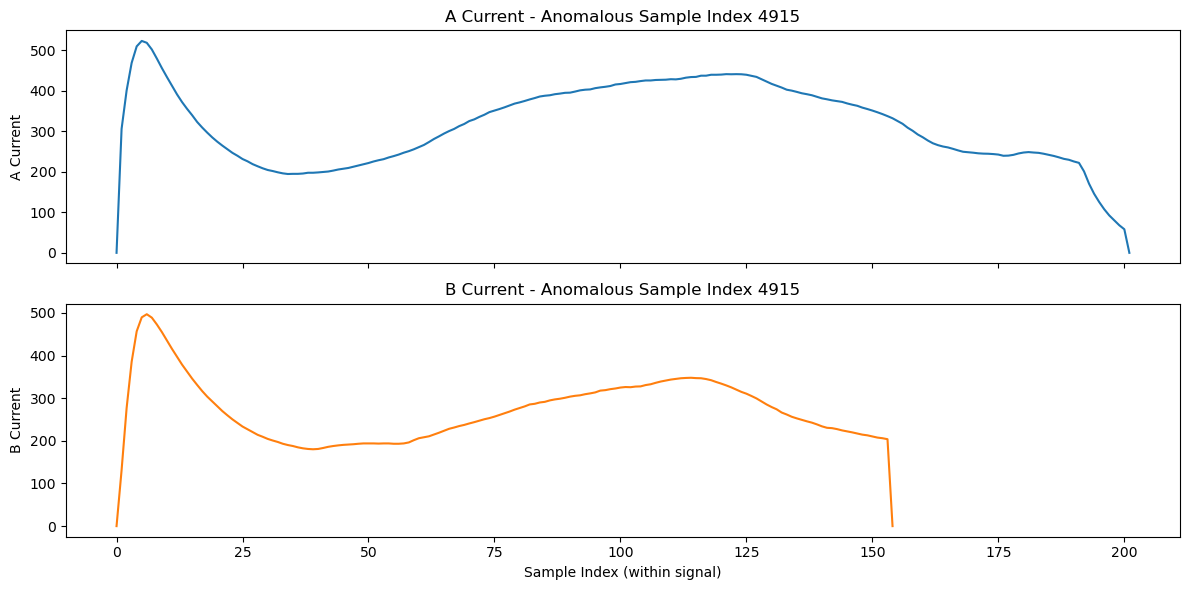

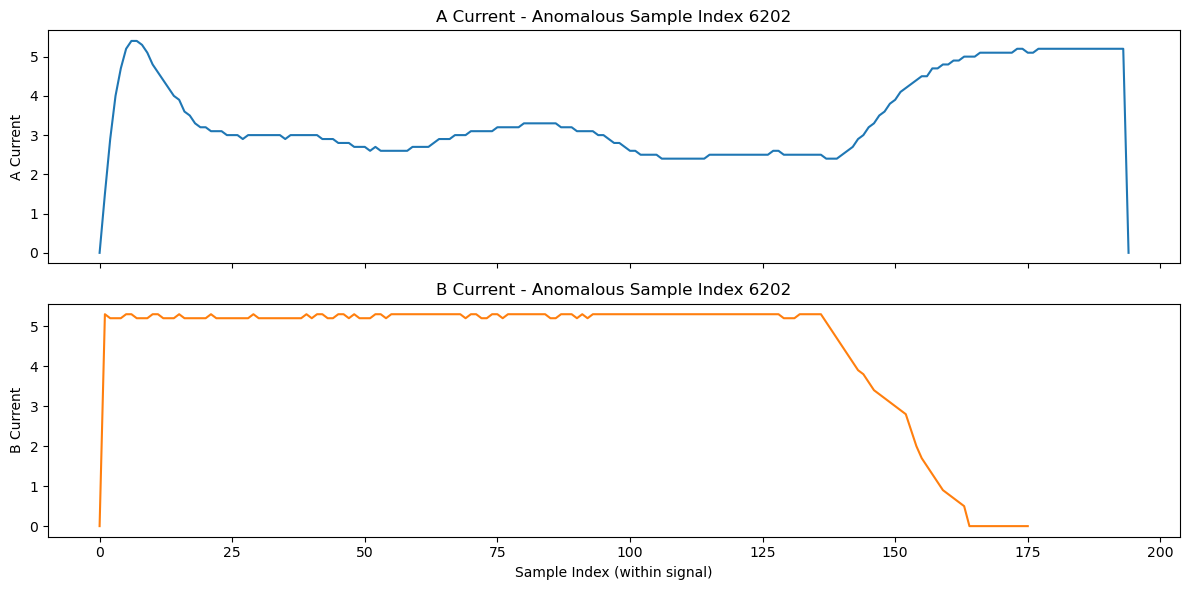

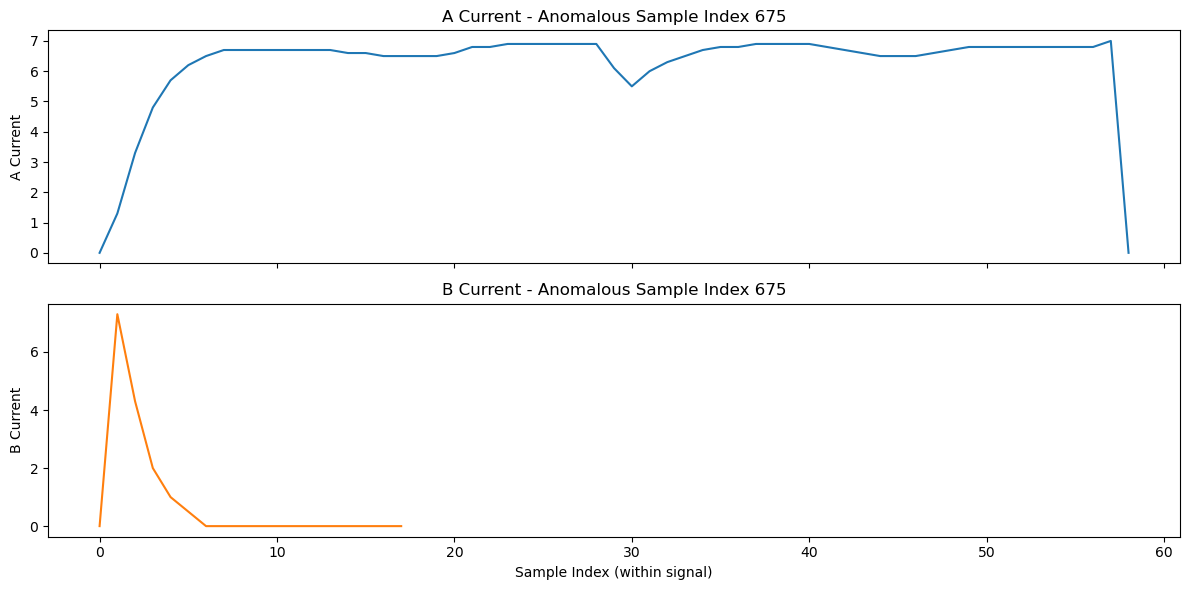

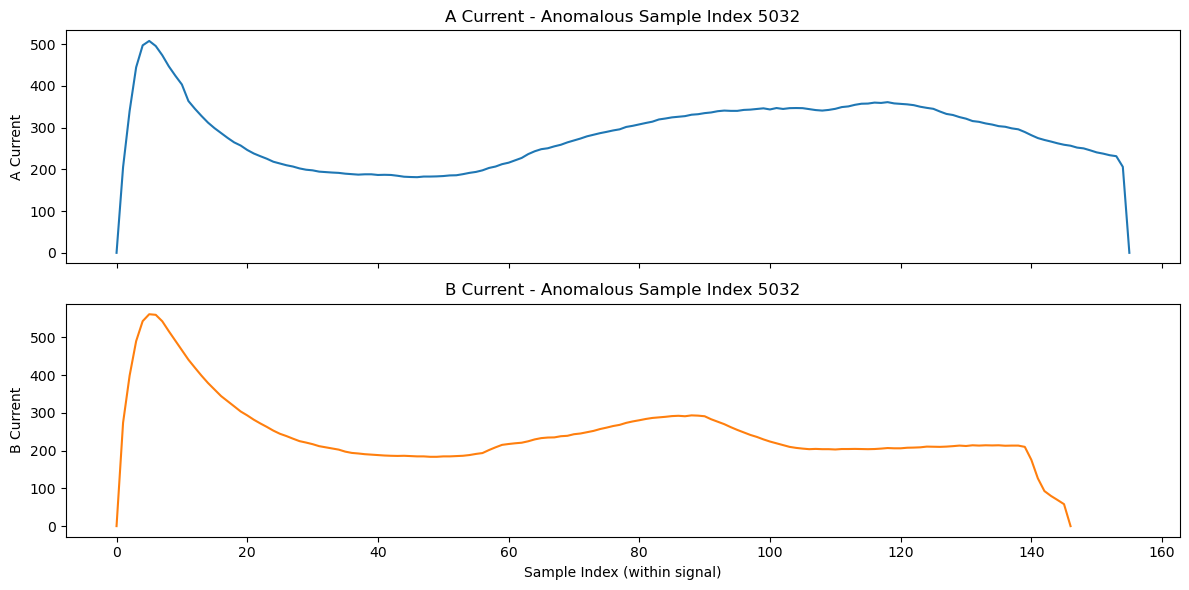

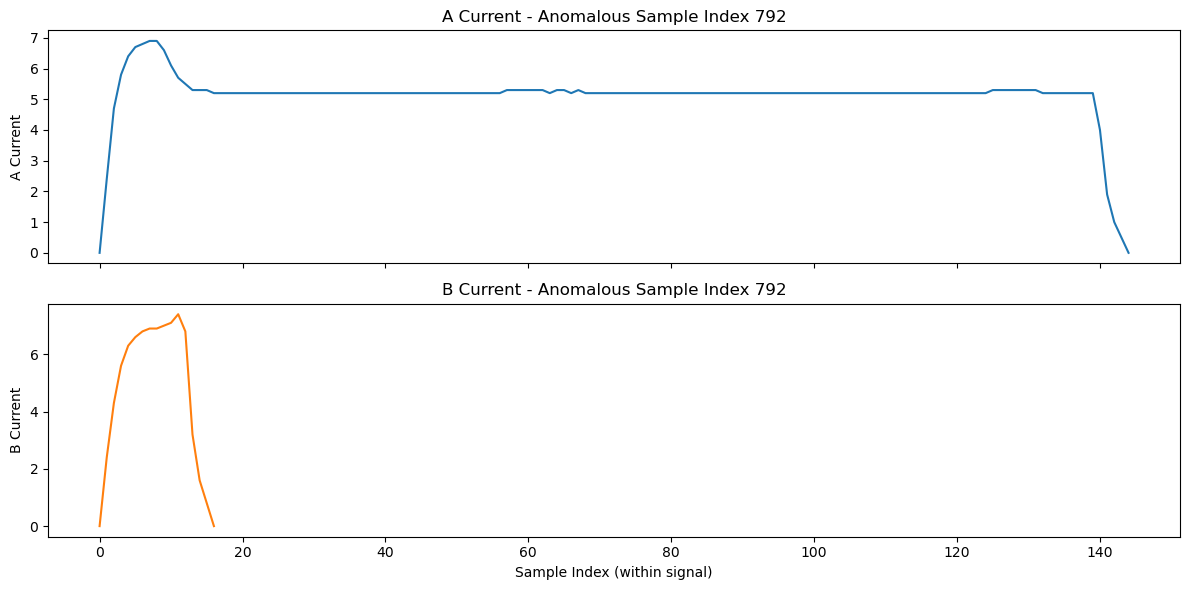

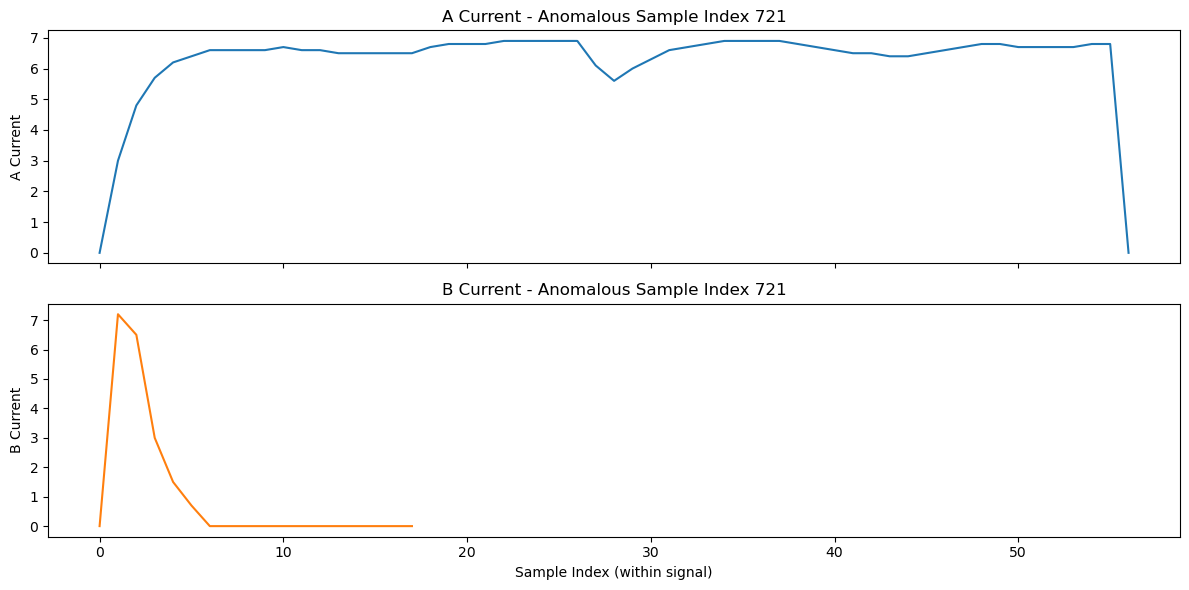

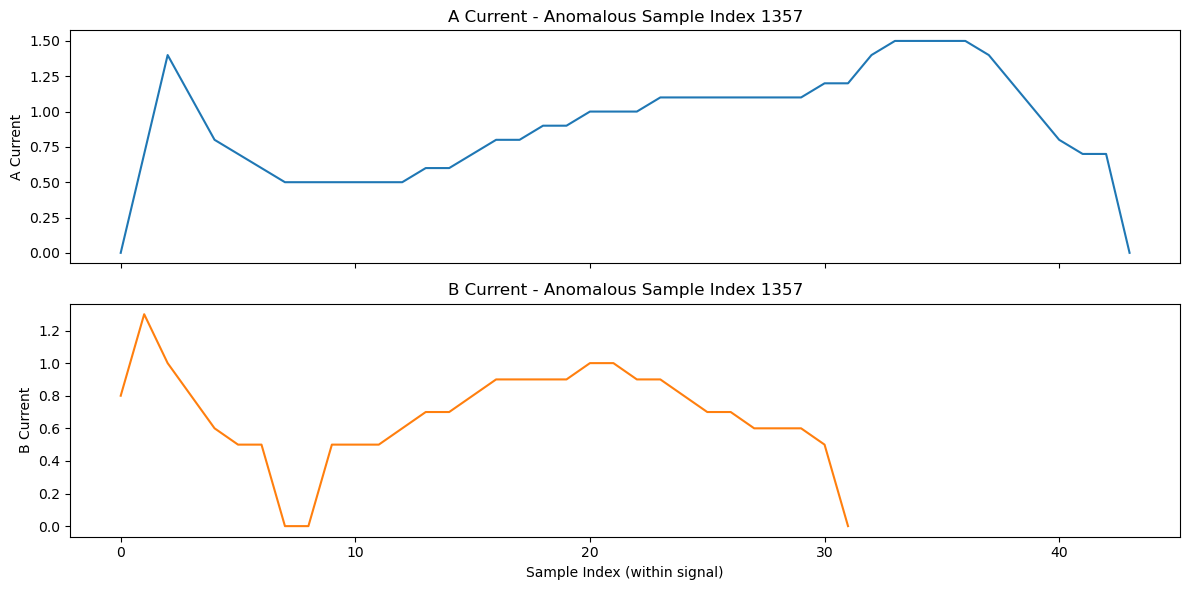

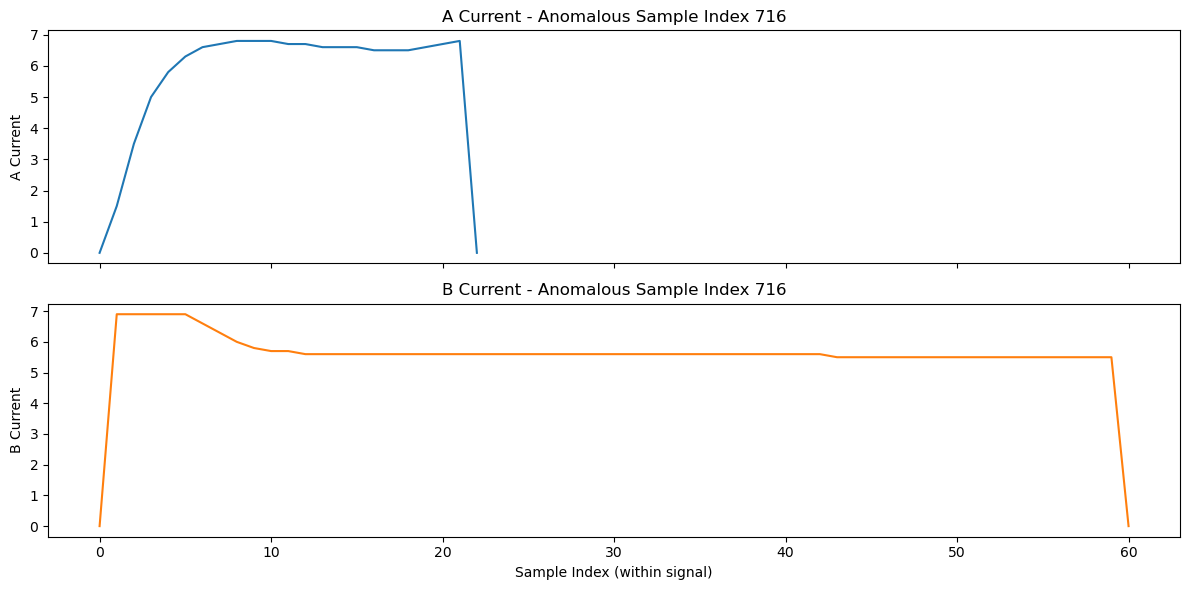

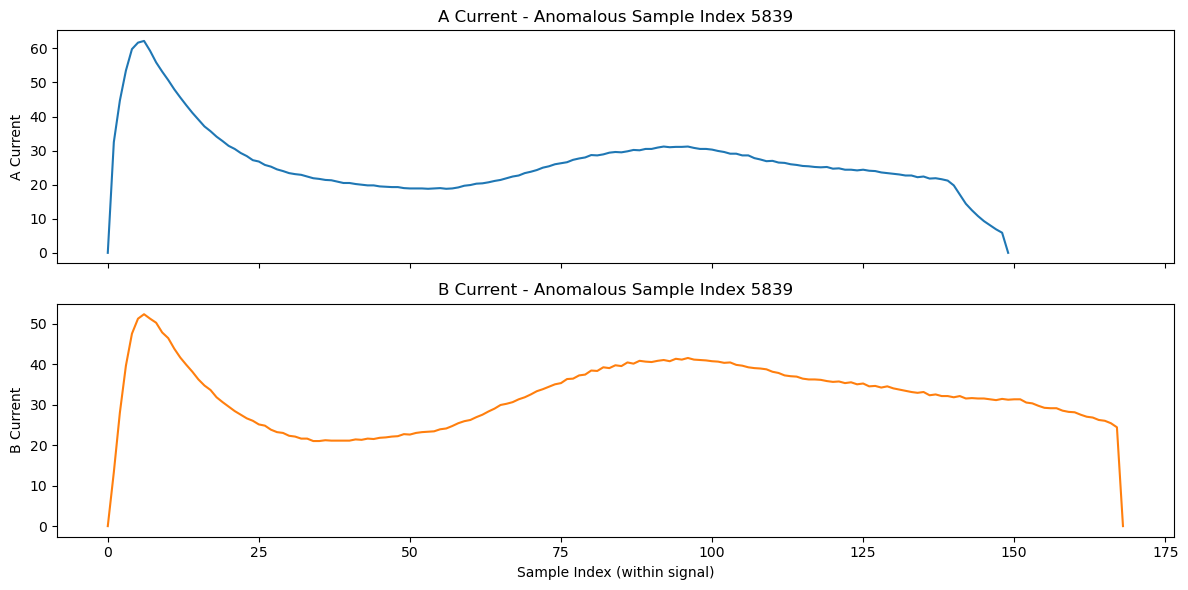

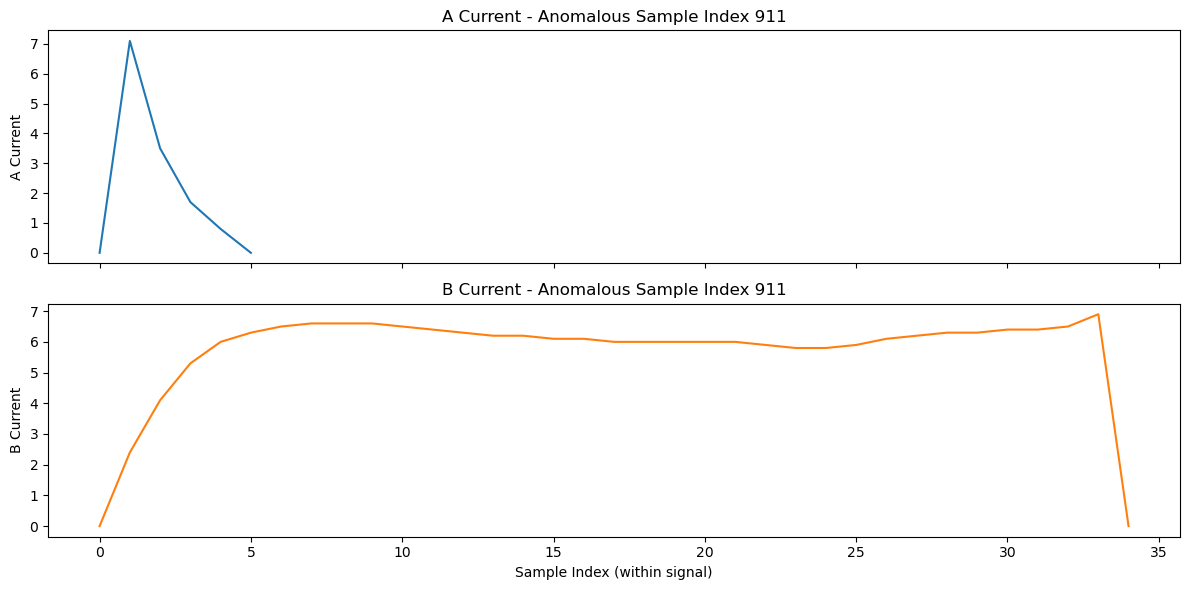

In [8]:
# Plot each anomalous sample in a separate figure
for idx in sample_indices:
    a_current = df.loc[idx, 'A Current']
    b_current = df.loc[idx, 'B Current']

    fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
    axes[0].plot(a_current, color='tab:blue')
    axes[0].set_title(f'A Current - Anomalous Sample Index {idx}')
    axes[0].set_ylabel('A Current')

    axes[1].plot(b_current, color='tab:orange')
    axes[1].set_title(f'B Current - Anomalous Sample Index {idx}')
    axes[1].set_ylabel('B Current')
    axes[1].set_xlabel('Sample Index (within signal)')

    plt.tight_layout()
    plt.show()